# Predicción de Afluencia del Metro de la Ciudad de México

## 1. Exploración preliminar del dataframe

In [1]:
# Importando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('/content/visualizaciones',exist_ok=True)

In [2]:
# Dataframe
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/refs/heads/main/Data/processed/afluencia_metro_2010_2025.zip'
df_raw = pd.read_csv(url,compression='zip')
df_raw.head()

,fecha,anio,linea,estacion,afluencia,mes_num,mes_nom
0,2010-01-01,2010,Línea 1,Zaragoza,20227,1,enero
1,2010-01-01,2010,Línea 1,Isabel la Católica,6487,1,enero
2,2010-01-01,2010,Línea 1,Moctezuma,10304,1,enero
3,2010-01-01,2010,Línea 1,Pino Suárez,8679,1,enero
4,2010-01-01,2010,Línea 1,Gómez Farías,19499,1,enero


### 1.1 Convertir fecha a ```datetime```

In [3]:
df = df_raw.copy()
df['fecha'] = pd.to_datetime(df['fecha'],errors='coerce')
df['fecha'].dtype

dtype('<M8[ns]')

### 1.2 Obtener día de la fecha

In [4]:
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.day_name()
df['dia_semana'] = df['dia_semana'].replace({
    'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
    'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado',
    'Sunday':'Domingo'
})
df['dia_semana'].unique()
df.head()

,fecha,anio,linea,estacion,afluencia,mes_num,mes_nom,dia,dia_semana
0,2010-01-01,2010,Línea 1,Zaragoza,20227,1,enero,1,Viernes
1,2010-01-01,2010,Línea 1,Isabel la Católica,6487,1,enero,1,Viernes
2,2010-01-01,2010,Línea 1,Moctezuma,10304,1,enero,1,Viernes
3,2010-01-01,2010,Línea 1,Pino Suárez,8679,1,enero,1,Viernes
4,2010-01-01,2010,Línea 1,Gómez Farías,19499,1,enero,1,Viernes


### 1.3 Correción en Meses

In [5]:
df['mes_nom'] = df['mes_nom'].replace({
    'enero':'Enero','febrero':'Febrero','marzo':'Marzo','abril':'Abril',
    'mayo':'Mayo','junio':'Junio','julio':'Julio','agosto':'Agosto',
    'septiembre':'Septiembre','octubre':'Octubre','noviembre':'Noviembre',
    'diciembre':'Diciembre'
})
df['mes_nom'].unique()

array(['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio',
       'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'],
      dtype=object)

In [6]:
# Colores del Metro
sns.set_theme(style='darkgrid')
metro_color = '#FE5000'
colores_metro = {
    'Línea 1':'#F04E98',
    'Línea 2':'#005EB8',
    'Línea 3':'#AF9800',
    'Línea 4':'#6BBBAE',
    'Línea 5':'#FFD100',
    'Línea 6':'#DA291C',
    'Línea 7':'#E87722',
    'Línea 8':'#009444',
    'Línea 9':'#512F2E',
    'Línea A':'#981D97',
    'Línea B':'#B1B3B3',
    'Línea 12':'#B0A32A'
}


## 2. Visualizaciones de las variables

In [7]:
# Copia del DataFrame para hacer visualizaciones
df_vis = df.copy()

# Orden Días de la semana
dias_semana = [
    'Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo'
]

# Ordenando días de la semana
df_vis['dia_semana'] = pd.Categorical(
    df_vis['dia_semana'],
    categories=dias_semana,
    ordered=True
)
# Orden Meses
meses = [
    'Enero','Febrero','Marzo','Abril','Mayo','Junio',
    'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre'
]

df_vis['mes_nom'] = pd.Categorical(
    df['mes_nom'],
    categories=meses,
    ordered=True
)

### 2.1 Variable Objetivo

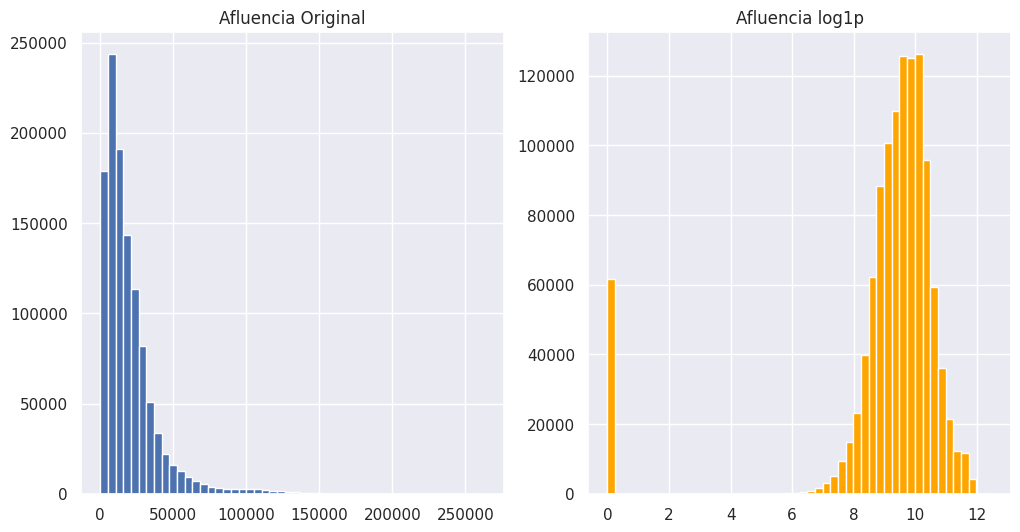

In [8]:
# Distribucción y skewness
fig, axes = plt.subplots(1,2,figsize=(12,6))
df_vis['afluencia'].hist(bins=50,ax=axes[0])
np.log1p(df_vis['afluencia']).hist(bins=50,ax=axes[1],color='orange')
axes[0].set_title('Afluencia Original')
axes[1].set_title('Afluencia log1p')
plt.show()

### 2.2 Variables Temporales

/tmp/ipykernel_223/3743119262.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis.groupby('dia_semana')['afluencia'].mean().plot(


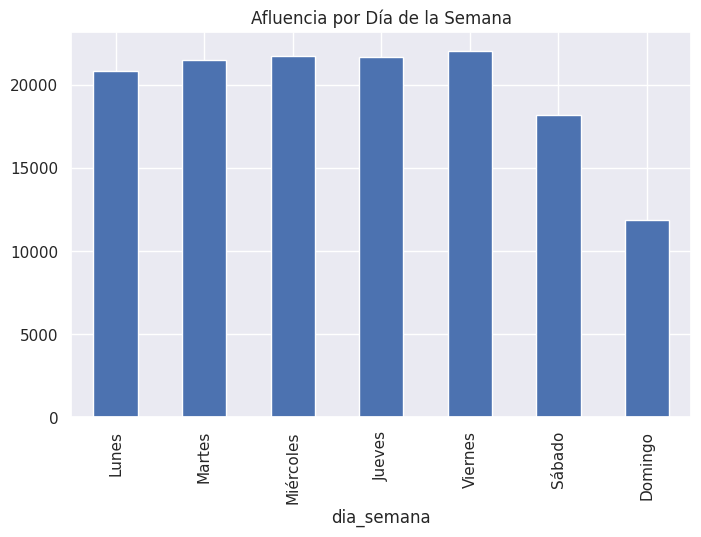

In [9]:
# Afluencia por Día de la semana
df_vis.groupby('dia_semana')['afluencia'].mean().plot(
    figsize=(8,5),
    kind='bar',
    title='Afluencia por Día de la Semana'
)
plt.savefig('/content/visualizaciones/01_perfil_semanal.png',
            dpi=150,bbox_inches='tight')
plt.show()

/tmp/ipykernel_223/700166216.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis.groupby('mes_nom')['afluencia'].mean().plot(


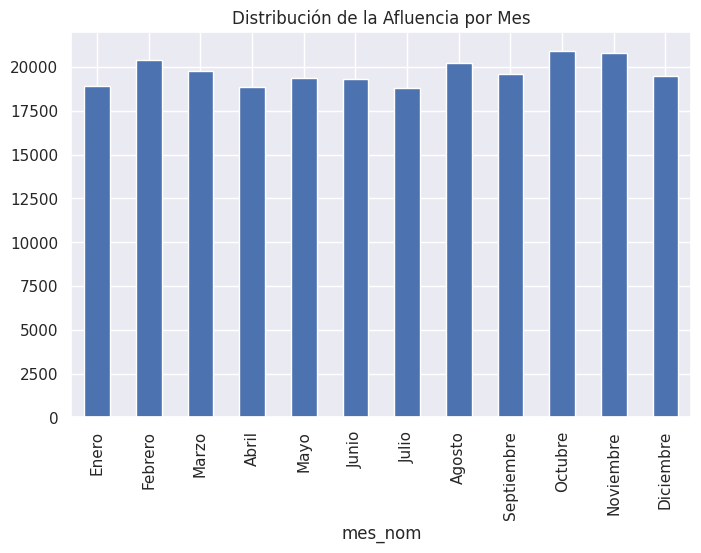

In [10]:
# Mes
df_vis.groupby('mes_nom')['afluencia'].mean().plot(
    figsize=(8,5),kind='bar',title='Distribución de la Afluencia por Mes')
plt.savefig('/content/visualizaciones/02_distribucion_mes.png',
            dpi=150,bbox_inches='tight')
plt.show()

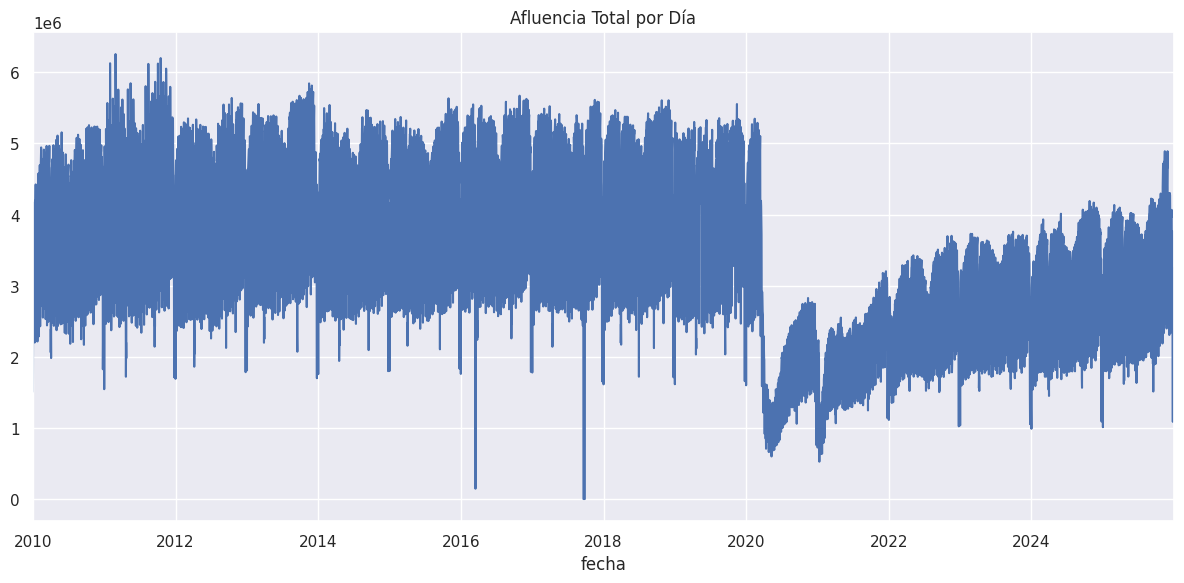

In [11]:
# Afluencia total
df_vis.groupby('fecha')['afluencia'].sum().plot(
    figsize=(12,6),title='Afluencia Total por Día')
plt.tight_layout()
plt.savefig('/content/visualizaciones/03_afluencia_total.png',
            dpi=150,bbox_inches='tight')
plt.show()

/tmp/ipykernel_223/3419526985.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vis.groupby(['dia_semana','mes_nom'])['afluencia'].mean().unstack()


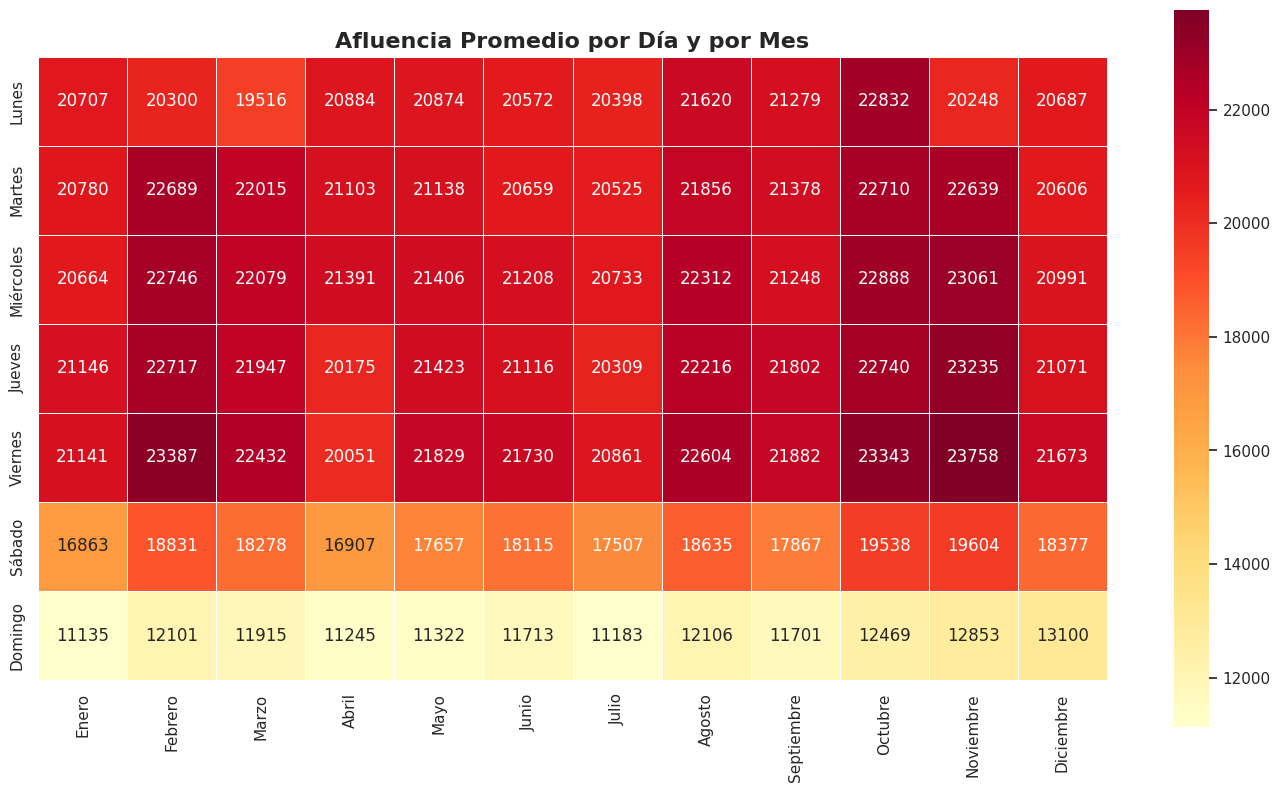

In [12]:
# Tabla Pivote
pivot = (
    df_vis.groupby(['dia_semana','mes_nom'])['afluencia'].mean().unstack()
)

# Visualizacion
plt.figure(figsize=(14,8))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True,
    linewidth=0.5,
    square=True,
    fmt='.0f'
)
plt.xlabel('')
plt.ylabel('')
plt.title('Afluencia Promedio por Día y por Mes',fontsize=16,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/04_heatmap_correlacion.png',
            dpi=150,bbox_inches='tight')
plt.show()

## 3. Sets de entrenamiento, validación y prueba

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from xgboost import XGBRegressor

### Trabajos previos

In [14]:
# Afluencia diaria por linea
df_lineas = (
    df.groupby(['fecha','linea'])['afluencia'].sum().reset_index()
)

# Conviertiendo linea a 'category'
df_lineas['linea'] = df_lineas['linea'].astype('category')

#### Feature Engineering

In [15]:
df_lineas['anio'] = df_lineas['fecha'].dt.year
df_lineas['mes'] = df_lineas['fecha'].dt.month
df_lineas['dia'] = df_lineas['fecha'].dt.day
df_lineas['dia_semana'] = df_lineas['fecha'].dt.day_of_week
df_lineas['dia_anio'] = df_lineas['fecha'].dt.dayofyear
df_lineas['es_fin_de_semana'] = (df_lineas['dia_semana'] >= 5).astype(int)
df_lineas.head()


,fecha,linea,afluencia,anio,mes,dia,dia_semana,dia_anio,es_fin_de_semana
0,2010-01-01,Línea 1,251474,2010,1,1,4,1,0
1,2010-01-01,Línea 12,0,2010,1,1,4,1,0
2,2010-01-01,Línea 2,285403,2010,1,1,4,1,0
3,2010-01-01,Línea 3,228261,2010,1,1,4,1,0
4,2010-01-01,Línea 4,24340,2010,1,1,4,1,0


### División de conjuntos de entrenamiento,validación y prueba

In [16]:
df_lineas = df_lineas.sort_values('fecha')
# Set de entrenamiento: Datos de entrenamiento de 2010 a 2023
train = df_lineas[df_lineas['fecha'] <'2024-01-01']
print(train.head(5))
print(train.tail(5))

        fecha    linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
0  2010-01-01  Línea 1     251474  2010    1    1           4         1   
11 2010-01-01  Línea B     191834  2010    1    1           4         1   
10 2010-01-01  Línea A      90993  2010    1    1           4         1   
9  2010-01-01  Línea 9      94283  2010    1    1           4         1   
7  2010-01-01  Línea 7      56191  2010    1    1           4         1   

    es_fin_de_semana  
0                  0  
11                 0  
10                 0  
9                  0  
7                  0  
           fecha     linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
61348 2023-12-31   Línea 4      29756  2023   12   31           6       365   
61347 2023-12-31   Línea 3     160070  2023   12   31           6       365   
61346 2023-12-31   Línea 2     214653  2023   12   31           6       365   
61345 2023-12-31  Línea 12      61010  2023   12   31           6       365   
61349 2023-12-31

In [17]:
# Set de Validacion: Datos de  2024
val = df_lineas[(df_lineas['fecha'] >= '2024-01-01') & (df_lineas['fecha'] < '2025-01-01')]

print(val.head(5))
print(val.tail(5))


           fecha    linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
61363 2024-01-01  Línea 7      47324  2024    1    1           0         1   
61366 2024-01-01  Línea A      76475  2024    1    1           0         1   
61365 2024-01-01  Línea 9      54958  2024    1    1           0         1   
61367 2024-01-01  Línea B     147541  2024    1    1           0         1   
61364 2024-01-01  Línea 8     107188  2024    1    1           0         1   

       es_fin_de_semana  
61363                 0  
61366                 0  
61365                 0  
61367                 0  
61364                 0  
           fecha     linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
65739 2024-12-31   Línea 3     291506  2024   12   31           1       366   
65738 2024-12-31   Línea 2     361417  2024   12   31           1       366   
65737 2024-12-31  Línea 12     198988  2024   12   31           1       366   
65736 2024-12-31   Línea 1     163877  2024   12   31      

In [18]:
# Set de Prueba: Datos de 2025
test  = df_lineas[df_lineas['fecha'] >= '2025-01-01']
print(test.head(5))
print(test.tail(5))

           fecha    linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
65759 2025-01-01  Línea B     122295  2025    1    1           2         1   
65758 2025-01-01  Línea A      79618  2025    1    1           2         1   
65757 2025-01-01  Línea 9      63290  2025    1    1           2         1   
65756 2025-01-01  Línea 8      96768  2025    1    1           2         1   
65755 2025-01-01  Línea 7      53497  2025    1    1           2         1   

       es_fin_de_semana  
65759                 0  
65758                 0  
65757                 0  
65756                 0  
65755                 0  
           fecha     linea  afluencia  anio  mes  dia  dia_semana  dia_anio  \
70117 2025-12-31  Línea 12     215923  2025   12   31           2       365   
70116 2025-12-31   Línea 1     319037  2025   12   31           2       365   
70126 2025-12-31   Línea A     175938  2025   12   31           2       365   
70120 2025-12-31   Línea 4      49946  2025   12   31      

In [19]:
# Tamaño de los sets
print(train.shape, val.shape, test.shape)

(61356, 9) (4392, 9) (4380, 9)


### OneHotEncoder

In [20]:
# Encoder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

encoder.fit(train[['linea']])
train_encoded = encoder.transform(train[['linea']])
val_encoded = encoder.transform(val[['linea']])
test_encoded = encoder.transform(test[['linea']])

# Nombre de columnas
columnas = encoder.get_feature_names_out(['linea'])


In [21]:
# Convirtiendo a DF

train_encoded = pd.DataFrame(
    train_encoded,columns=columnas,index=train.index
)
val_encoded = pd.DataFrame(
    val_encoded,columns=columnas,index=val.index
)
test_encoded = pd.DataFrame(
    test_encoded,columns=columnas,index=test.index
)

# Concatenar
train = pd.concat([train.drop(columns=['linea']),train_encoded],axis=1)
val   = pd.concat([val.drop(columns=['linea']), val_encoded], axis=1)
test  = pd.concat([test.drop(columns=['linea']), test_encoded], axis=1)

# Tamaño
print("Tamaño de entrenamiento",train.shape)
print("Tamaño de validacion",val.shape)
print("Tamaño de prueba",test.shape)

Tamaño de entrenamiento (61356, 20)
Tamaño de validacion (4392, 20)
Tamaño de prueba (4380, 20)


### Variables predictoras y objetivo

In [22]:
features = ['anio','mes','dia','dia_semana','dia_anio','es_fin_de_semana']
features += [col for col in train.columns if col.startswith('linea_')]

# Entrenamiento
X_train = train[features]
y_train = train['afluencia']

# Validacion
X_val = val[features]
y_val = val['afluencia']
# Prueba
X_test = test[features]
y_test = test['afluencia']

print('X_train tamaño', X_train.shape)
print('y_train tamaño', y_train.shape)
print('X_val tamaño', X_val.shape)
print('y_val tamaño', y_val.shape)
print('X_test tamaño', X_test.shape)
print('y_test tamaño', y_test.shape)

X_train tamaño (61356, 18)
y_train tamaño (61356,)
X_val tamaño (4392, 18)
y_val tamaño (4392,)
X_test tamaño (4380, 18)
y_test tamaño (4380,)


### Modelo

In [23]:
model1 = XGBRegressor(
    n_estimators = 2000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=10,
    early_stopping_rounds=50,
    random_state=42
)
# Entrenar
model1.fit(
    X_train,
    y_train,
    eval_set=[(X_val,y_val)],
    verbose=False
)
print("Mejor iteración:",model1.best_iteration)

Mejor iteración: 218


In [24]:
# Predicción
y_val_pred = model1.predict(X_val)

# Evaluacion para Validación
mae_val = mean_absolute_error(y_val,y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val,y_val_pred))
r2_val = r2_score(y_val,y_val_pred)

print(f" MAE: {mae_val:.2f} | RMSE: {rmse_val:.2f} | R²: {r2_val:.3f}")

 MAE: 37659.35 | RMSE: 59496.90 | R²: 0.861


In [25]:
# Predicción
y_test_pred = model1.predict(X_test)

# Evaluacion para Validación
mae_test = mean_absolute_error(y_test,y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test,y_test_pred))
r2_test = r2_score(y_test,y_test_pred)

print(f" MAE: {mae_test:.2f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.3f}")

# Guardar predicciones
test['prediccion'] = y_test_pred

 MAE: 49890.53 | RMSE: 82505.92 | R²: 0.743


## 4. Visualizaciones

### Scatter plot real vs predicho

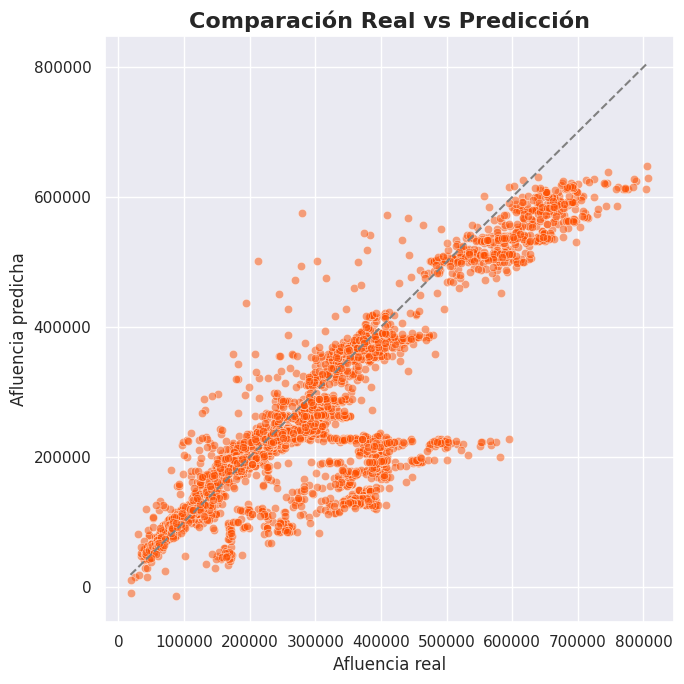

In [26]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, color="#fe5000")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--', color='gray')
plt.xlabel("Afluencia real")
plt.ylabel("Afluencia predicha")
plt.title("Comparación Real vs Predicción",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/05_comparacion_rvsp1.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfico de errores

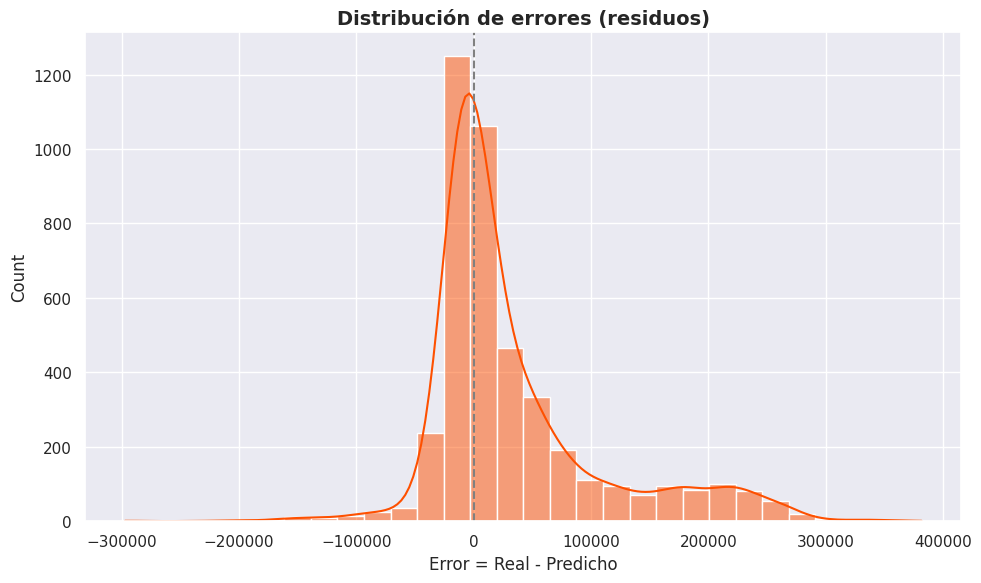

In [27]:
residuos = y_test - y_test_pred
plt.figure(figsize=(10,6))
sns.histplot(
    residuos,
    bins=30,
    kde=True,
    color='#FE5000'
)
plt.axvline(0,color='gray',linestyle='--')
plt.xlabel('Error = Real - Predicho')
plt.title('Distribución de errores (residuos)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/06_distribucion_errores', dpi=150, bbox_inches='tight')
plt.show()

### Barplot de error medio absoluto (MAE) por línea

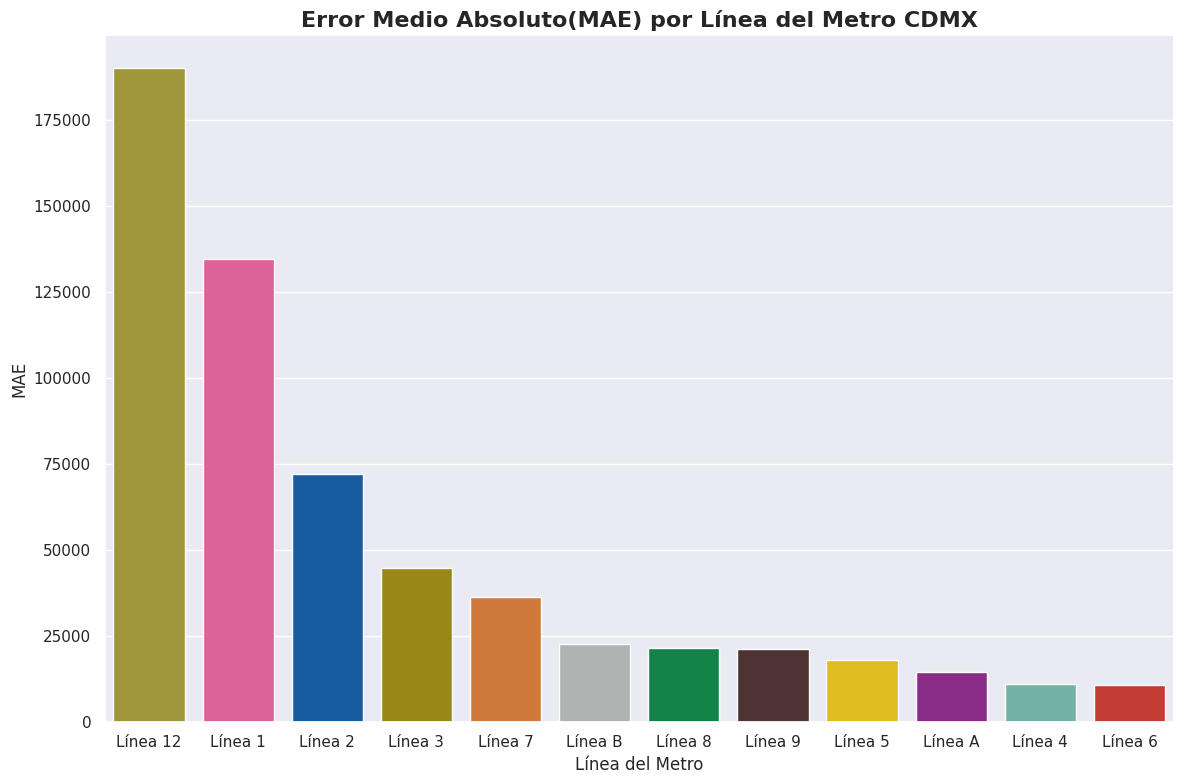

In [28]:
test_df = X_test.copy()
test_df['real'] = y_test
test_df['pred'] = y_test_pred
cols_lineas = [c for c in test_df.columns if c.startswith('linea_')]
test_df['linea'] = test_df[cols_lineas].idxmax(axis=1).str.replace('linea_','')

test_df['error_abs'] = abs(test_df['real']-test_df['pred'])

mae_por_linea = (
    test_df
    .groupby('linea')['error_abs']
    .mean().sort_values(ascending=False)
)
plt.figure(figsize=(12,8))
sns.barplot(
    x=mae_por_linea.index,
    y=mae_por_linea.values,
    palette=colores_metro,
    hue=mae_por_linea.index
)
plt.title('Error Medio Absoluto(MAE) por Línea del Metro CDMX',fontsize=16,
          fontweight='bold')
plt.ylabel('MAE')
plt.xlabel('Línea del Metro')
plt.tight_layout()
plt.savefig('/content/visualizaciones/07_mae_linea.png', dpi=150, bbox_inches='tight')
plt.show()

### Real vs Predicho por Línea

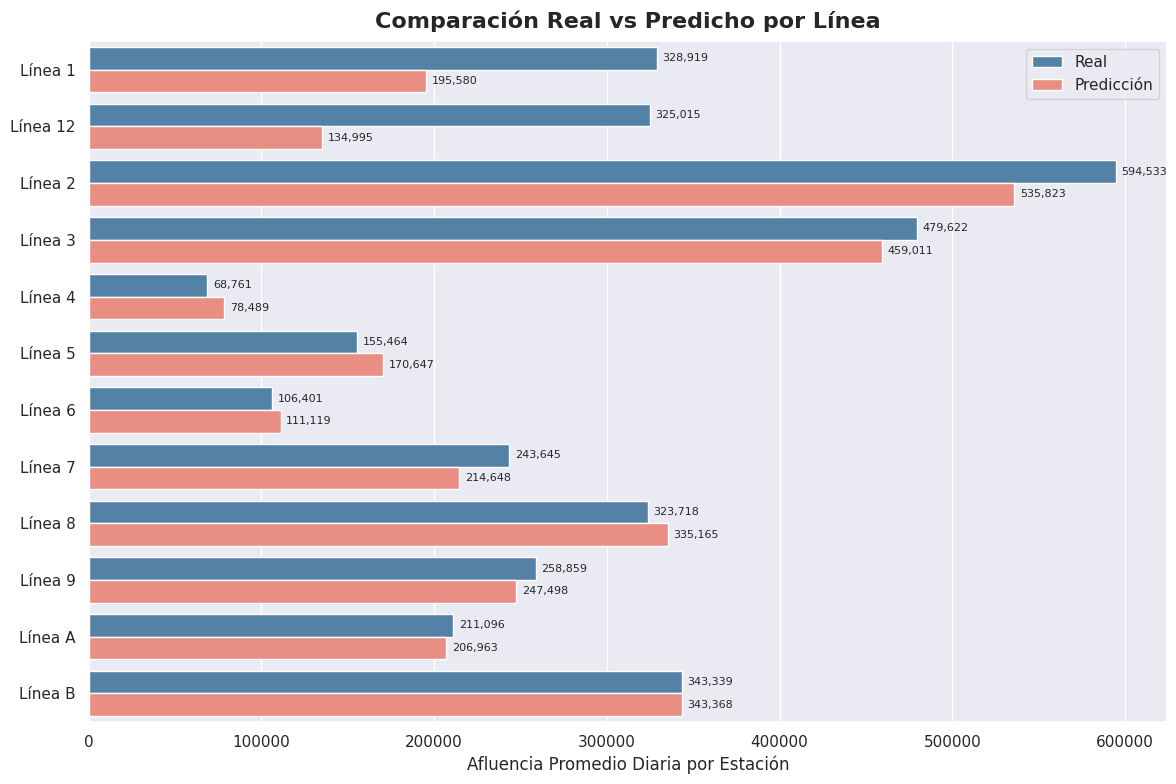

In [29]:
import matplotlib.ticker as mticker
comparacion_linea = (
    test_df
    .groupby('linea')[['real','pred']]
    .mean().reset_index()
)
comparacion_linea_melt = comparacion_linea.melt(
    id_vars='linea',
    value_vars=['real','pred'],
    var_name='Tipo',
    value_name='Afluencia'
)

plt.figure(figsize=(12,8))
ax = sns.barplot(
    data=comparacion_linea_melt,
    y='linea',
    x='Afluencia',
    hue='Tipo',
    palette={'real':'steelblue','pred':'salmon'},
    orient='h',
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Real','Predicción'],
    title=''
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}',padding=4,fontsize=8)
plt.xlabel('Afluencia Promedio Diaria por Estación')
plt.ylabel('')
plt.title('Comparación Real vs Predicho por Línea',fontsize=16,fontweight='bold',
          pad=10)
plt.tight_layout()
plt.savefig('/content/visualizaciones/08_barras_comp.png', dpi=150, bbox_inches='tight')
plt.show()

### Gráfico de Dispersión (Real vs Predicho)

#### Scatter General

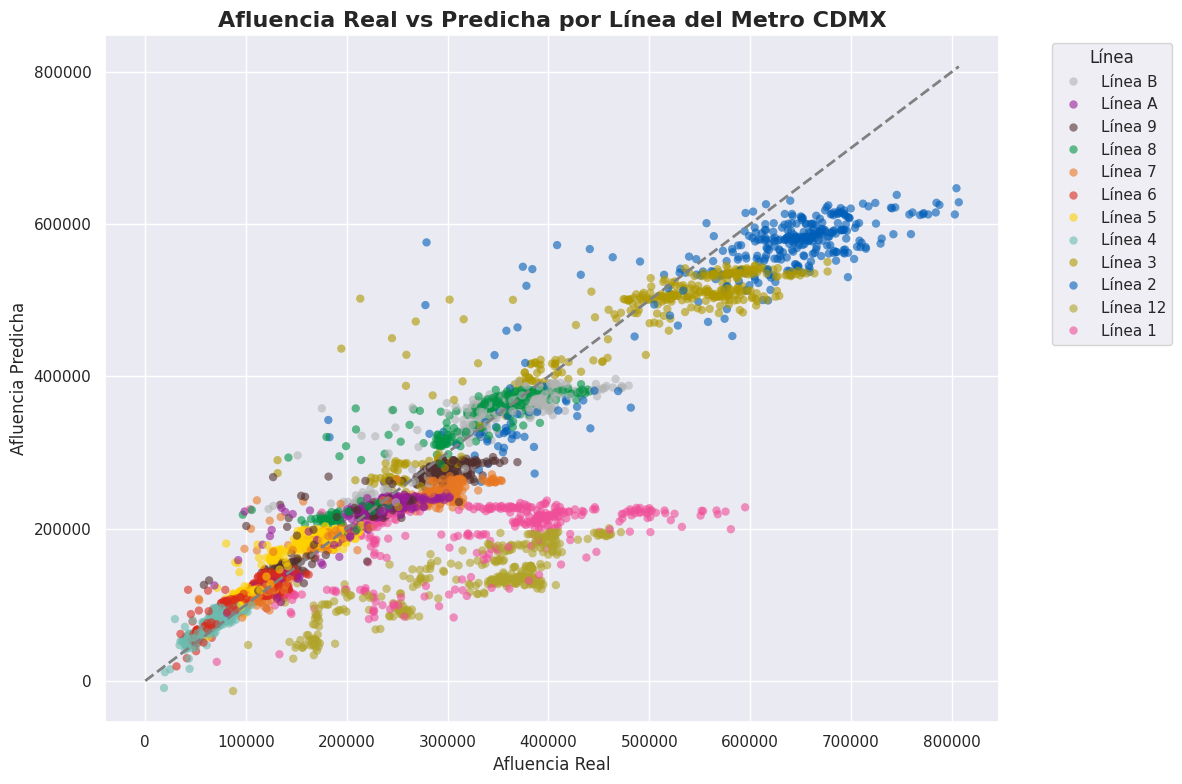

In [30]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=test_df,
    x='real',
    y='pred',
    hue='linea',
    palette=colores_metro,
    alpha=0.6,
    edgecolor='none'
)

# Diagonal ideal (perfect prediction)
max_val = max(test_df['real'].max(), test_df['pred'].max())
plt.plot([0, max_val], [0, max_val], '--', color='gray', lw=2)

plt.title('Afluencia Real vs Predicha por Línea del Metro CDMX', fontsize=16, fontweight='bold')
plt.xlabel('Afluencia Real')
plt.ylabel('Afluencia Predicha')
plt.legend(title='Línea', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/visualizaciones/09_real_predic_linea', dpi=150, bbox_inches='tight')
plt.show()


#### Subplots

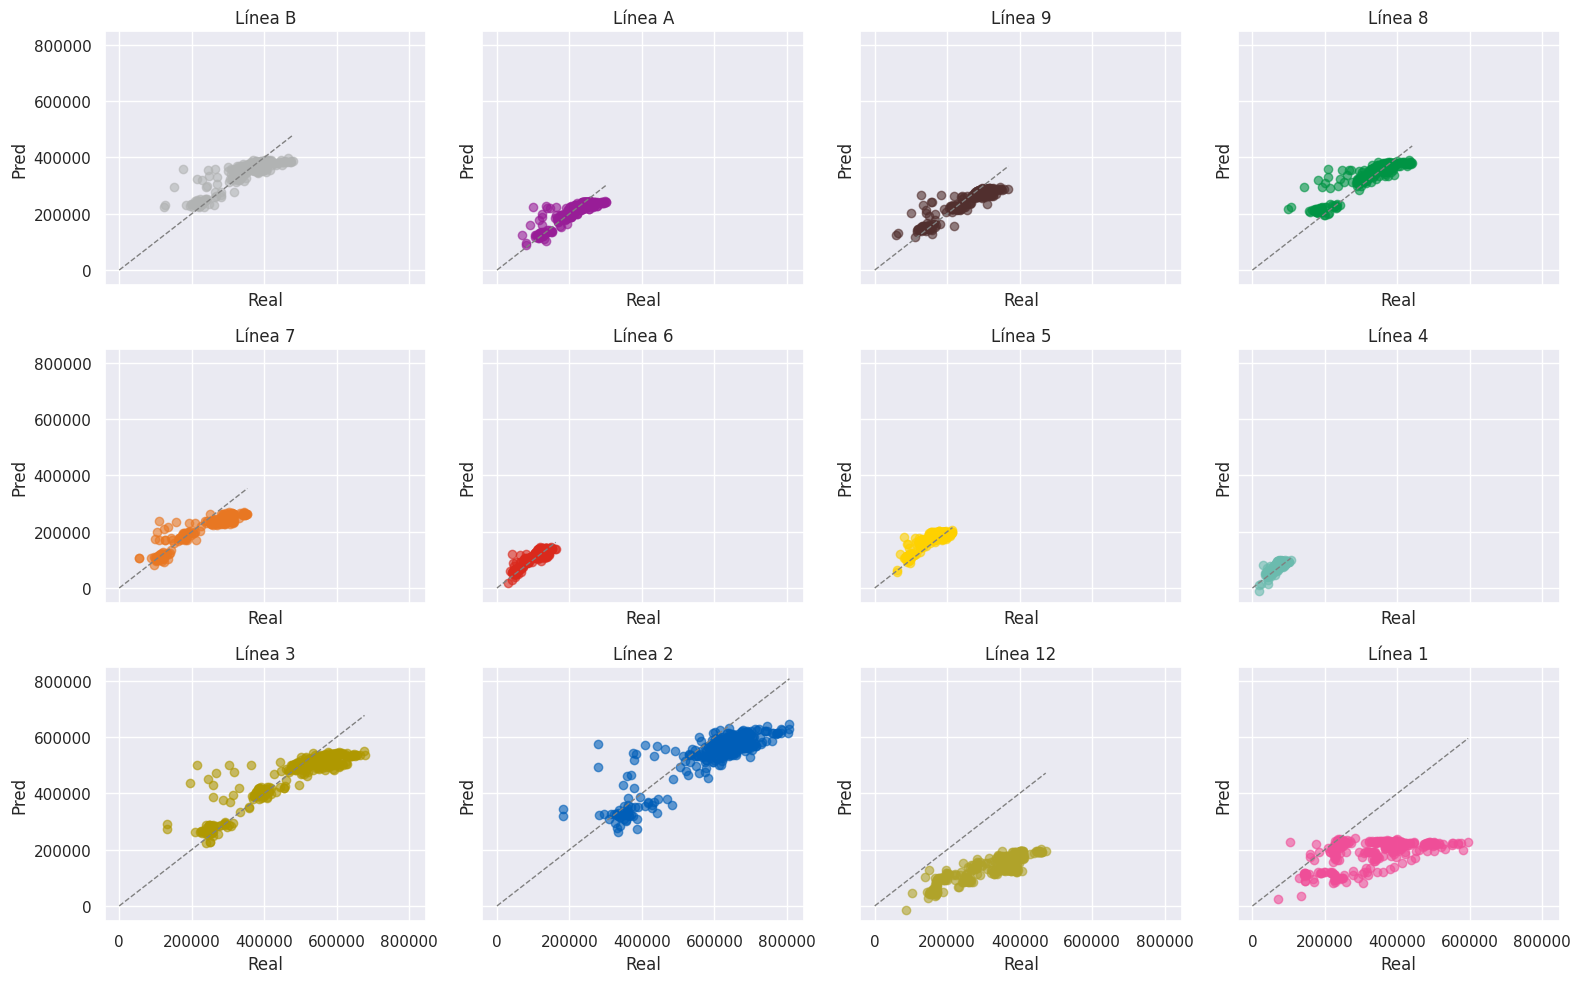

In [31]:
lineas = test_df['linea'].unique()
n = len(lineas)
cols = 4
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, linea in enumerate(lineas):
    subset = test_df[test_df['linea'] == linea]
    axes[i].scatter(subset['real'], subset['pred'], color=colores_metro.get(linea, '#999999'), alpha=0.6)
    axes[i].plot([0, subset['real'].max()], [0, subset['real'].max()], '--', color='gray', lw=1)
    axes[i].set_title(linea)
    axes[i].set_xlabel('Real')
    axes[i].set_ylabel('Pred')

plt.tight_layout()
plt.show()


/tmp/ipykernel_223/1666219147.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: r2_score(df['real'], df['pred']))


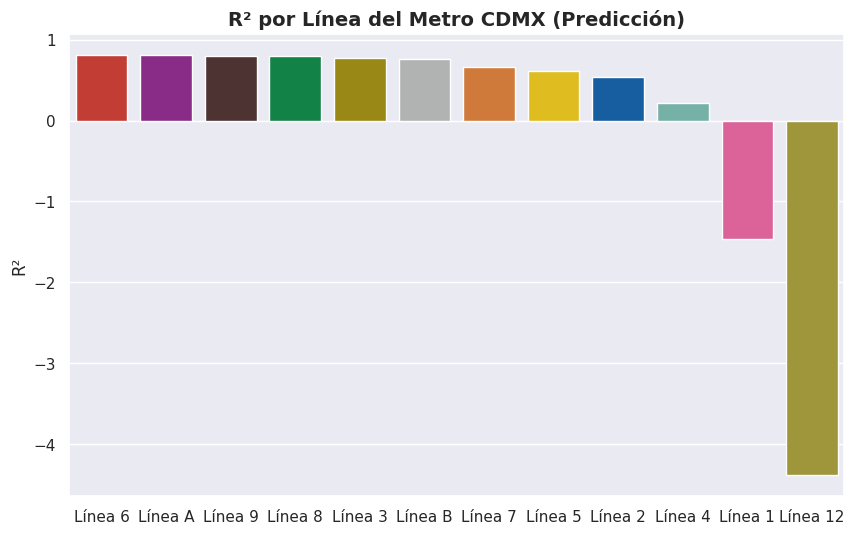

In [32]:
r2_por_linea = (
    test_df.groupby('linea')
          .apply(lambda df: r2_score(df['real'], df['pred']))
          .sort_values(ascending=False)
)

r2_por_linea = r2_por_linea.reset_index(name='R2')
plt.figure(figsize=(10,6))
sns.barplot(
    data=r2_por_linea,
    x='linea',
    y='R2',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('')
plt.ylabel('R²')
plt.title('R² por Línea del Metro CDMX (Predicción)',fontsize=14,fontweight='bold')
plt.show()

## 5. Modelo 2

### Normalizando variable objetivo

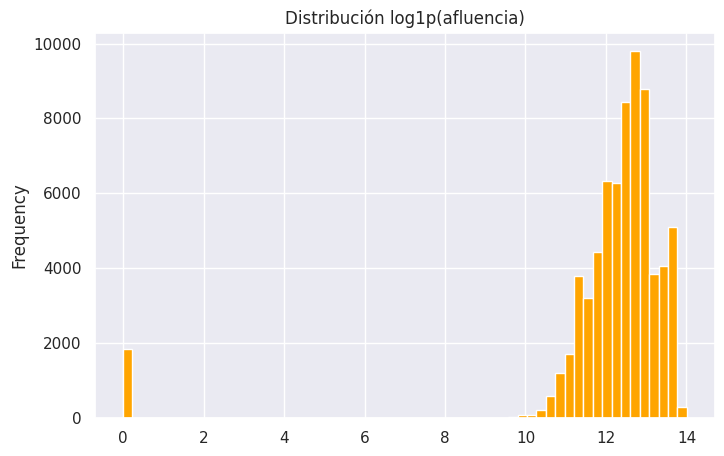

In [33]:
# Normalizar variable objetivo
df_modelo2 = df_lineas.copy()
df_modelo2['afluencia_log'] = np.log1p(df_modelo2['afluencia'])

plt.figure(figsize=(8,5))
df_modelo2['afluencia_log'].plot(kind='hist',bins=60,color='orange',
                                title='Distribución log1p(afluencia)')
plt.show()

### Agregando días festivos

In [34]:
import holidays
mx_holidays = holidays.Mexico(years=range(2010,2026))
# Fechas a datetime
fechas_feriado = pd.to_datetime(list(mx_holidays.keys()))
df_modelo2['es_feriado'] = df_modelo2['fecha'].isin(fechas_feriado).astype(int)


### Variables cíclicas, Lag Features y Rolling Windows

Como mes y día de la semana son variables circulares, habrá que modelar esa característica.

In [35]:
# Variables cícliclas
df_modelo2['mes_sin'] = np.sin(2*np.pi*df_modelo2['mes']/12)
df_modelo2['mes_cos'] = np.cos(2*np.pi*df_modelo2['mes']/12)

df_modelo2['dia_semana_sin'] = np.sin(2*np.pi*df_modelo2['dia_semana']/7)
df_modelo2['dia_semana_cos'] = np.cos(2*np.pi*df_modelo2['dia_semana']/7)

df_modelo2['dia_sin'] = np.sin(2*np.pi*df_modelo2['dia_semana']/31)
df_modelo2['dia_cos'] = np.cos(2*np.pi*df_modelo2['dia_semana']/31)
# Lag Features
df_modelo2 = df_modelo2.sort_values(['linea','fecha'])

df_modelo2['lag1'] = df_modelo2.groupby('linea')['afluencia'].shift(1)
df_modelo2['lag7']= df_modelo2.groupby('linea')['afluencia'].shift(7)
df_modelo2['lag14']= df_modelo2.groupby('linea')['afluencia'].shift(14)
df_modelo2['lag28']= df_modelo2.groupby('linea')['afluencia'].shift(28)

df_modelo2['rolling7'] = (
    df_modelo2.groupby('linea')['afluencia']
    .transform(lambda x: x.shift(1).rolling(7).mean())
)
df_modelo2['rolling14'] = (
    df_modelo2.groupby('linea')['afluencia']
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

df_modelo2['rolling30'] = (
    df_modelo2.groupby('linea')['afluencia']
    .transform(lambda x: x.shift(1).rolling(30).mean()))

/tmp/ipykernel_223/3414180030.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo2['lag1'] = df_modelo2.groupby('linea')['afluencia'].shift(1)
/tmp/ipykernel_223/3414180030.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo2['lag7']= df_modelo2.groupby('linea')['afluencia'].shift(7)
/tmp/ipykernel_223/3414180030.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo2['lag14']= df_modelo2.gr

### Sets de Entrenamiento y Prueba

In [36]:
# Set de Entrenamiento: 2010 a 2023
train2 = df_modelo2[df_modelo2['fecha'] <'2024-01-01']

# Set de Validacion: 2024
val2 = df_modelo2[(df_modelo2['fecha'] >= '2024-01-01') & (df_modelo2['fecha'] < '2025-01-01')]

# Set de Prueba: Datos de 2025
test2 = df_modelo2[df_modelo2['fecha'] >= '2025-01-01']

### One Hot Encoding

In [37]:
# Enconder
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder.fit(train2[['linea']])
train_encoded2 = encoder.transform(train2[['linea']])
val_encoded2 = encoder.transform(val2[['linea']])
test_encoded2 = encoder.transform(test2[['linea']])

# Nombres de columnas
columnas = encoder.get_feature_names_out(['linea'])

# Conviertiendo a DF
train_encoded2 = pd.DataFrame(
    train_encoded2,columns=columnas,index=train2.index
)

val_encoded2 = pd.DataFrame(
    val_encoded2,columns=columnas,index=val2.index
)

test_encoded2 = pd.DataFrame(
    test_encoded2,columns=columnas,index=test2.index
)

# Concatenar
train_2 = pd.concat([train2.drop(columns=['linea']),train_encoded2],axis=1)
val_2 = pd.concat([val2.drop(columns=['linea']), val_encoded2], axis=1)
test_2 = pd.concat([test2.drop(columns=['linea']), test_encoded2], axis=1)

# Tamaño
print("Tamaño de entrenamiento",train_2.shape)
print("Tamaño de validacion",val_2.shape)
print("Tamaño de prueba",test_2.shape)

Tamaño de entrenamiento (61356, 35)
Tamaño de validacion (4392, 35)
Tamaño de prueba (4380, 35)


### Variables predictoras y objetivo

In [38]:
features = ['anio','mes','dia','dia_semana','dia_anio','es_fin_de_semana','es_feriado',
            'mes_sin','mes_cos','dia_semana_sin','dia_semana_cos','dia_sin','dia_cos','lag1',
            'lag7','lag14','lag28','rolling7','rolling14','rolling30']
features += [c for c in train_2.columns if c.startswith('linea_')]

# Entrenamiento
X_train_2 = train_2[features]
y_train_2 = train_2['afluencia']

# Validacion
X_val_2 = val_2[features]
y_val_2 = val_2['afluencia']
# Prueba
X_test_2 = test_2[features]
y_test_2 = test_2['afluencia']

print('X_train tamaño', X_train_2.shape)
print('y_train tamaño', y_train_2.shape)
print('X_val tamaño', X_val_2.shape)
print('y_val tamaño', y_val_2.shape)
print('X_test tamaño', X_test_2.shape)
print('y_test tamaño', y_test_2.shape)

X_train tamaño (61356, 32)
y_train tamaño (61356,)
X_val tamaño (4392, 32)
y_val tamaño (4392,)
X_test tamaño (4380, 32)
y_test tamaño (4380,)


### Modelo 2

In [39]:
model2 = XGBRegressor(
    n_estimators = 2000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    min_child_weight=10,
    early_stopping_rounds=50,
    random_state=42
)

# Entrenar
model2.fit(
    X_train_2,
    y_train_2,
    eval_set = [(X_val_2,y_val_2)],
    verbose=False
)
print("Mejor iteración:",model2.best_iteration)

Mejor iteración: 446


In [40]:
# Predicción para validacion
y_val_pred2 = model2.predict(X_val_2)

# Evaluacion para Validacion
mae_val2 = mean_absolute_error(y_val_2,y_val_pred2)
rmse_val2 = np.sqrt(mean_squared_error(y_val_2,y_val_pred2))
r2_val2 = r2_score(y_val_2,y_val_pred2)
print(f" MAE: {mae_val2:.2f} | RMSE: {rmse_val2:.2f} | R²: {r2_val2:.3f}")

 MAE: 12600.35 | RMSE: 20767.46 | R²: 0.983


In [41]:
# Predicción para test
y_test_pred2 = model2.predict(X_test_2)

# Evaluacion para Validación
mae_test2 = mean_absolute_error(y_test_2,y_test_pred2)
rmse_test2 = np.sqrt(mean_squared_error(y_test_2,y_test_pred2))
r2_test2 = r2_score(y_test_2,y_test_pred2)

print(f" MAE: {mae_test2:.2f} | RMSE: {rmse_test2:.2f} | R²: {r2_test2:.3f}")
# Guardar predicciones
test_2['pred'] = y_test_pred2

 MAE: 13382.40 | RMSE: 22644.21 | R²: 0.981


### Visualizaciones

In [42]:
# Copia
test_df = test_2.copy()
# Reconstruyendo lineas
linea_cols = [c for c in test_df.columns if c.startswith('linea_')]
test_df['linea'] = test_df[linea_cols].idxmax(axis=1).str.replace('linea_','')

# Real
test_df['real'] = test_df['afluencia']

#### Feature Importance

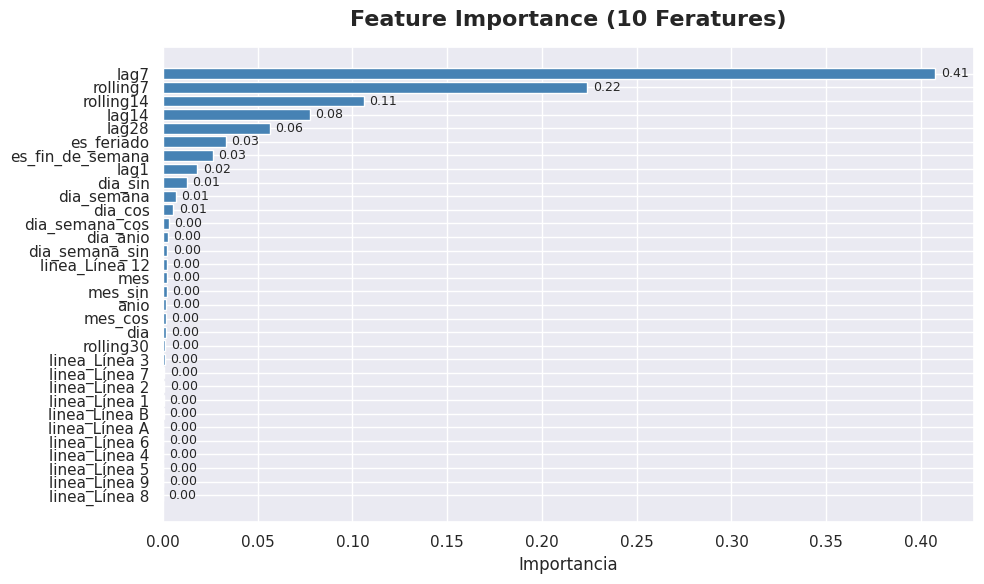

In [43]:
# Importances
importances = model2.feature_importances_

# Pasar a dataframe
fi_df = pd.DataFrame({
    'feature':features,
    'importance':importances
}).sort_values('importance',ascending=True)

# Visualizacion
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(
    fi_df['feature'],fi_df['importance'],color='steelblue'
)
ax.bar_label(bars, fmt='{:.2f}', padding=4, fontsize=9)
ax.set_xlabel('Importancia')
ax.set_title('Feature Importance (10 Feratures)',fontsize=16,fontweight='bold',pad=15)
plt.tight_layout()
plt.savefig('/content/visualizaciones/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Error por Línea

/tmp/ipykernel_223/3507774121.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.abs((g['real']-g['pred'])/g['real']))*100)


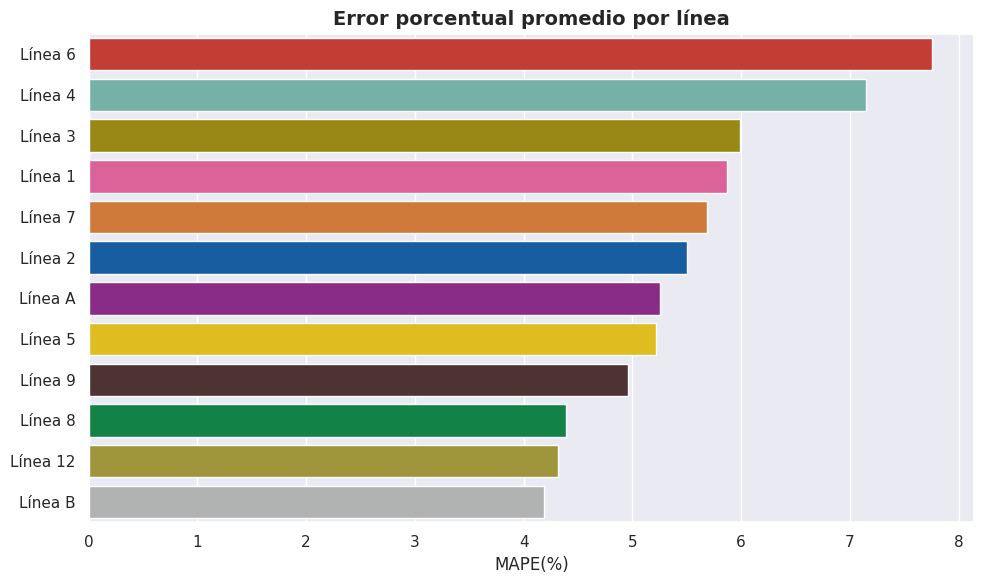

In [44]:
mape_linea = (
    test_df
    .groupby('linea')
    .apply(lambda g: np.mean(np.abs((g['real']-g['pred'])/g['real']))*100)
    .reset_index(name='MAPE')
    .sort_values('MAPE',ascending=False)
)

fig, ax = plt.subplots(figsize=(10,6))
bars = sns.barplot(
    data=mape_linea,
    y='linea',
    x='MAPE',
    palette=colores_metro,
    hue='linea'
)
ax.set_xlabel('MAPE(%)')
ax.set_ylabel('')
ax.set_title('Error porcentual promedio por línea',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/11_error_linea.png', dpi=150, bbox_inches='tight')
plt.show()

#### $R^{2}$ por línea

/tmp/ipykernel_223/3545861140.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: r2_score(g['real'],g['pred']))


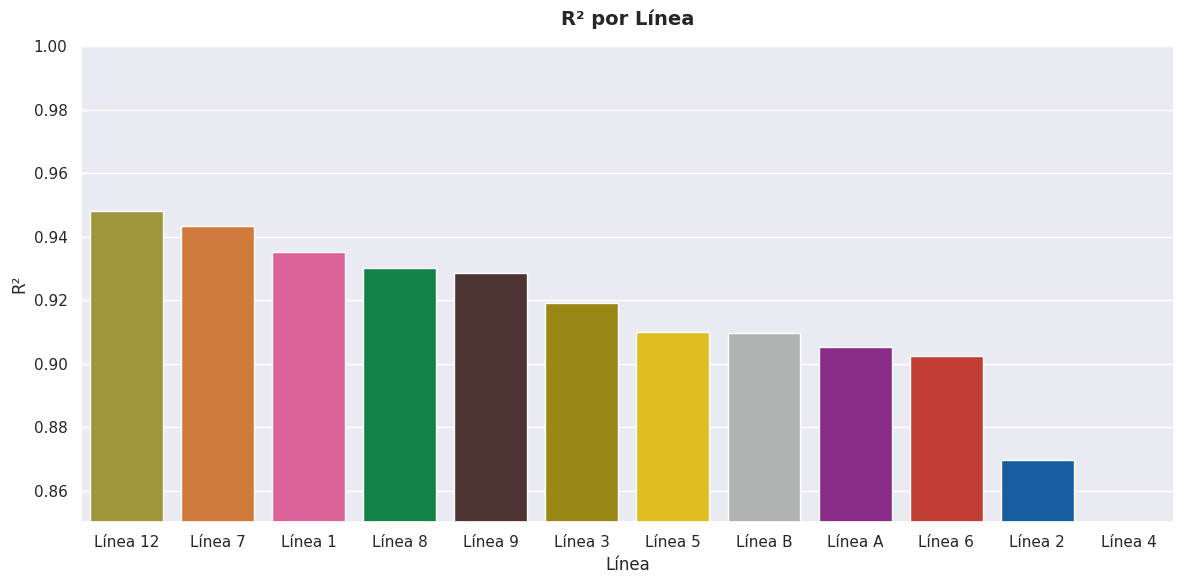

In [45]:
# Dataframe de r2
r2_linea = (
    test_df
    .groupby('linea')
    .apply(lambda g: r2_score(g['real'],g['pred']))
    .reset_index(name='R2')
    .sort_values(by='R2',ascending=False)
)
# Visualización
plt.figure(figsize=(12,6))
sns.barplot(
    data=r2_linea,
    x='linea',
    y='R2',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('Línea')
plt.ylabel('R²')
plt.ylim(0.85,1)
plt.title('R² por Línea',fontsize=14,fontweight='bold',pad=15)
plt.tight_layout()
plt.savefig('/content/visualizaciones/12_r2_linea.png', dpi=150, bbox_inches='tight')
plt.show()

#### Real vs Predicho


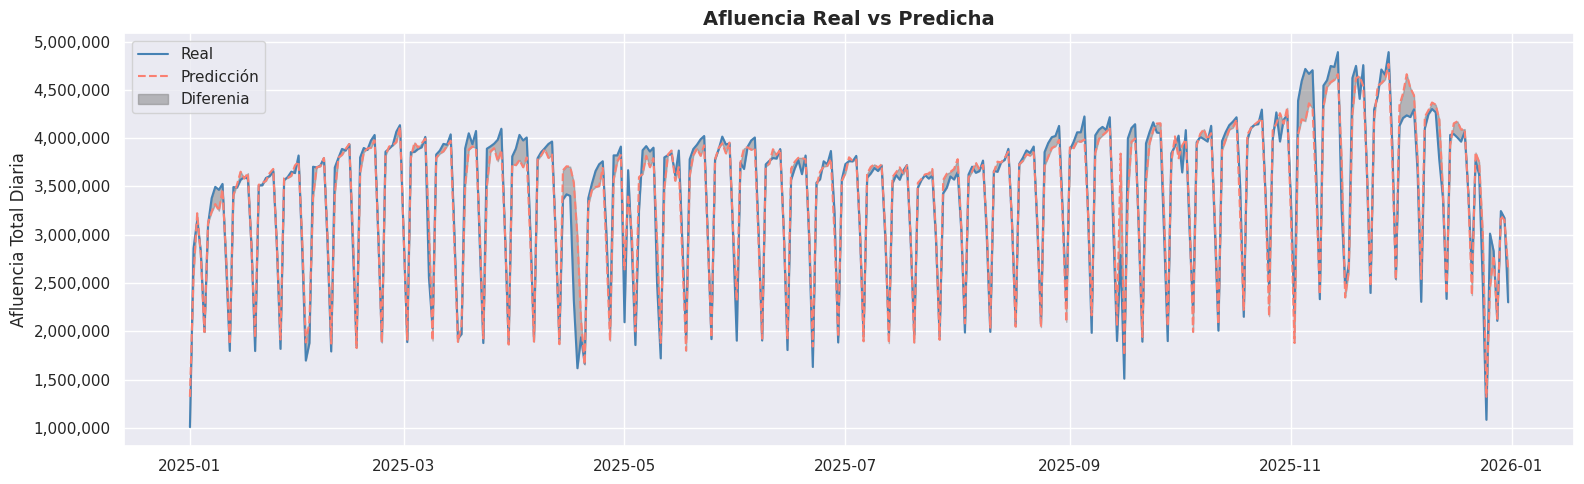

In [46]:
tiempo_df = (
    test_df
    .groupby('fecha')[['real','pred']]
    .sum()
    .reset_index()
    .sort_values('fecha')
)
plt.figure(figsize=(16,5))
# Afluencia Real
plt.plot(
    tiempo_df['fecha'],
    tiempo_df['real'],
    label='Real',
    color='steelblue',
    linewidth=1.5
)
# Afluencia Predicha
plt.plot(
    tiempo_df['fecha'],
    tiempo_df['pred'],
    label='Predicción',
    color='salmon',
    linewidth=1.5,
    linestyle='--'
)

# Diferencia
plt.fill_between(
    tiempo_df['fecha'],
    tiempo_df['real'],
    tiempo_df['pred'],
    alpha=0.5,color='gray',label='Diferenia'
)
plt.xlabel('')
plt.ylabel('Afluencia Total Diaria')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('Afluencia Real vs Predicha',fontsize=14,fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/content/visualizaciones/13_afluencia_real_pred.png', dpi=150, bbox_inches='tight')
plt.show()

#### Real vs Predicho por Línea

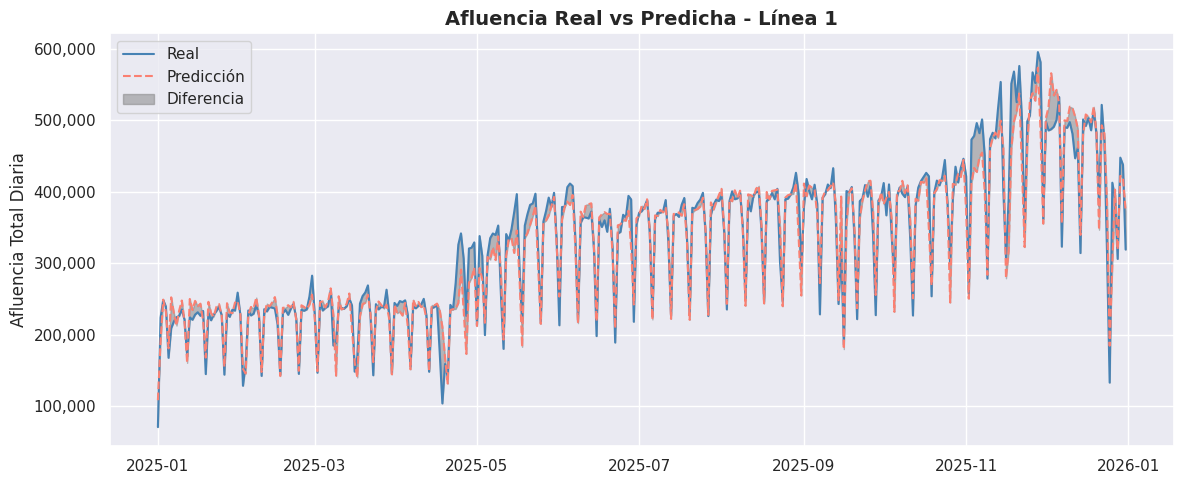

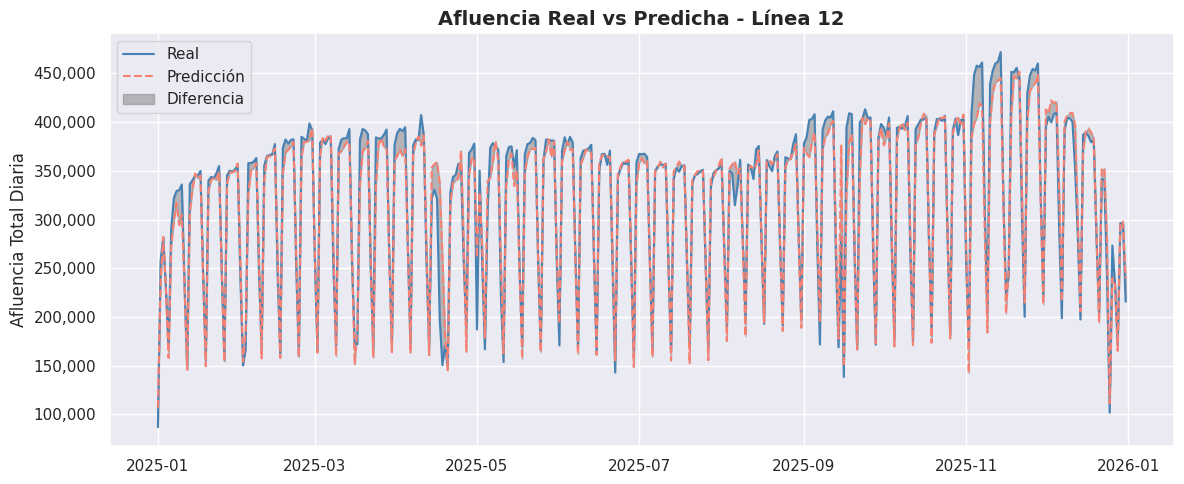

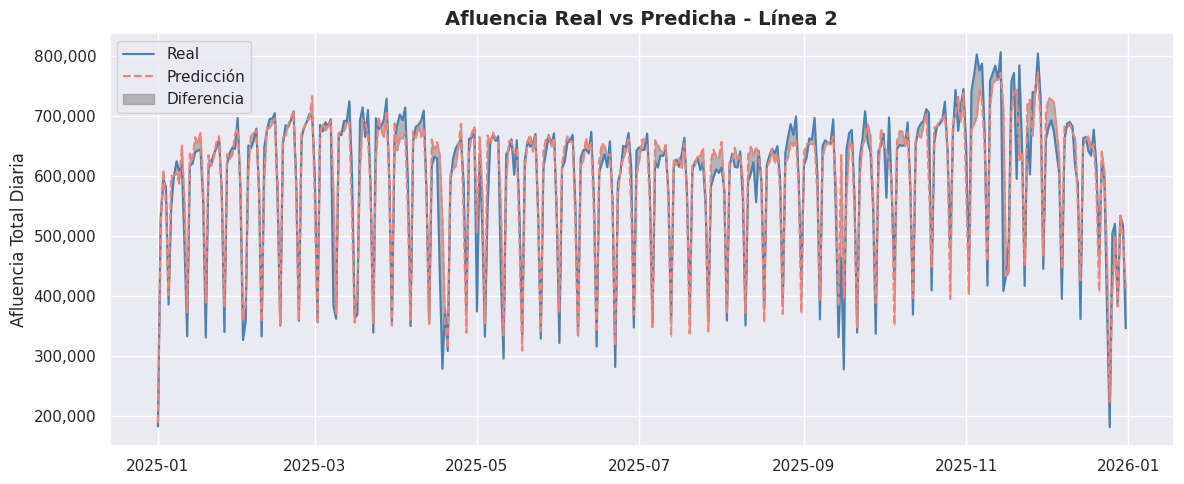

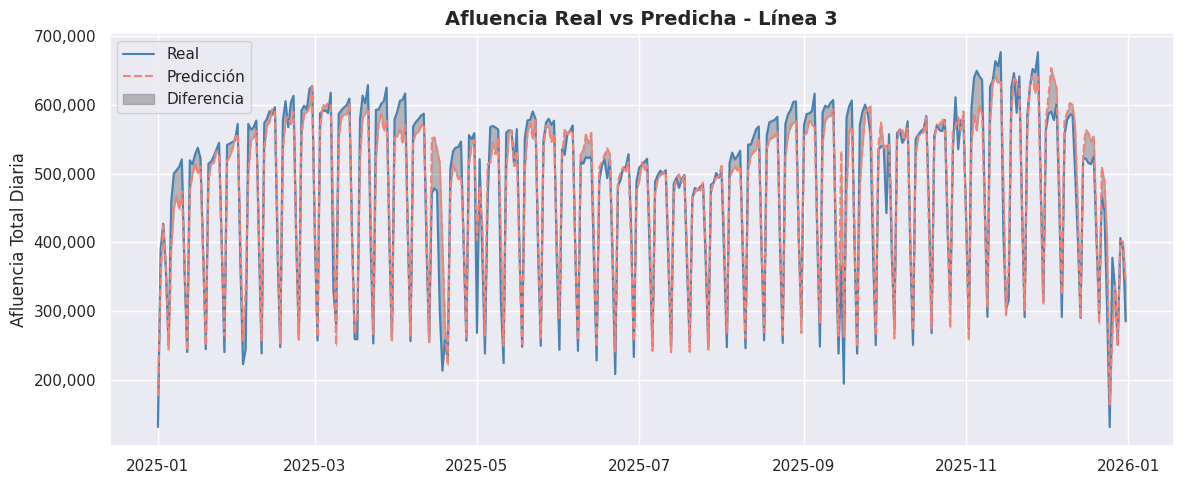

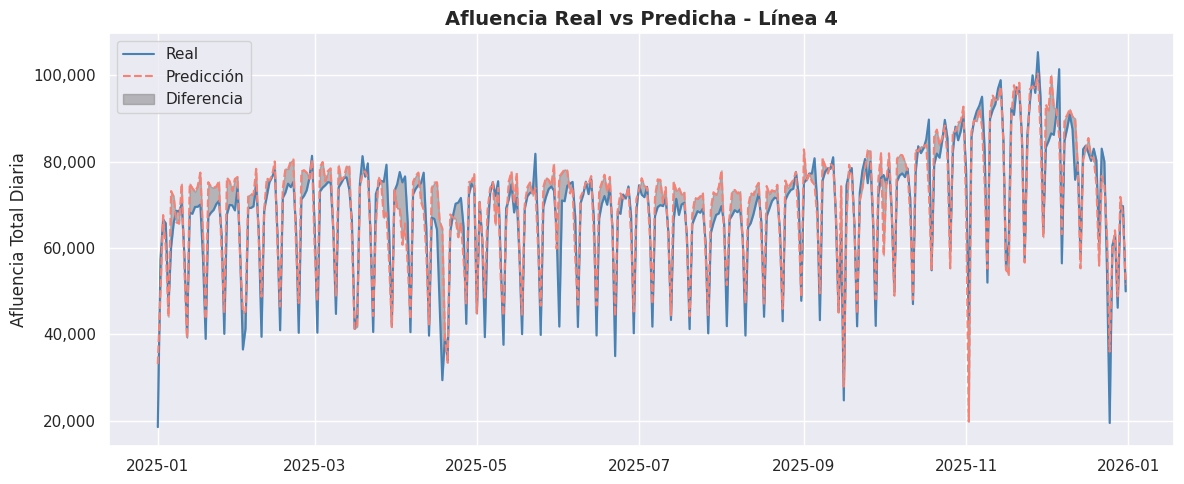

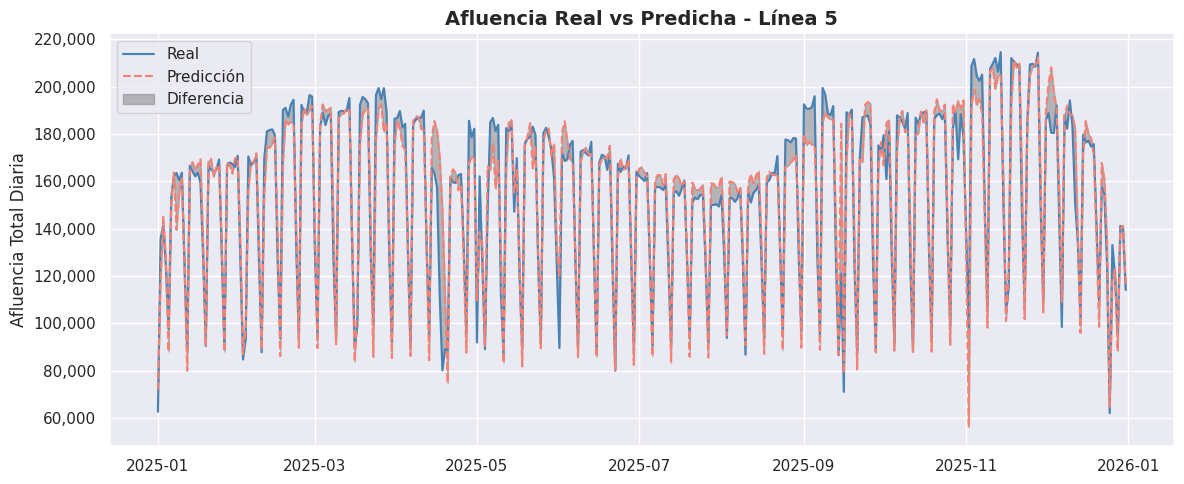

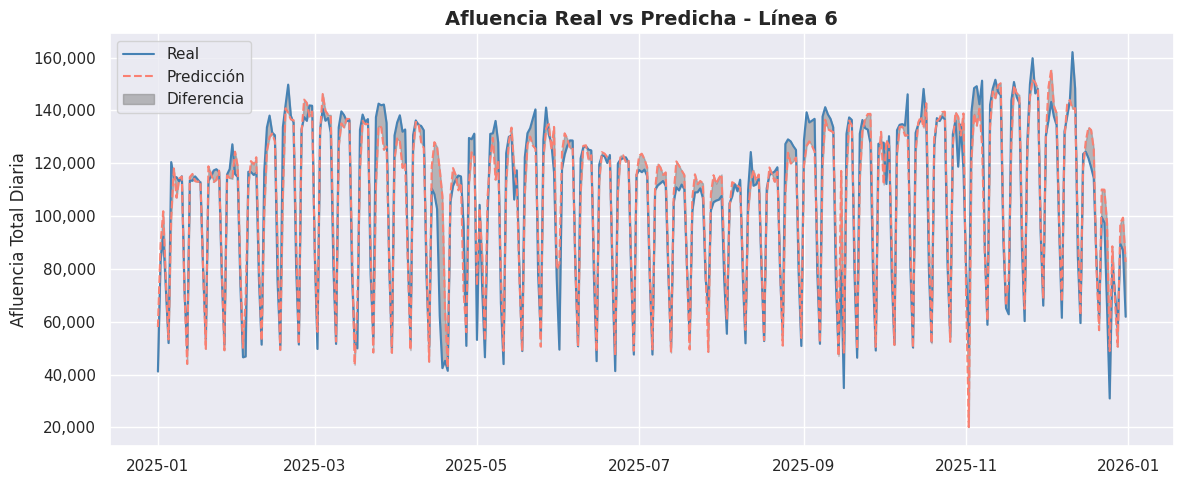

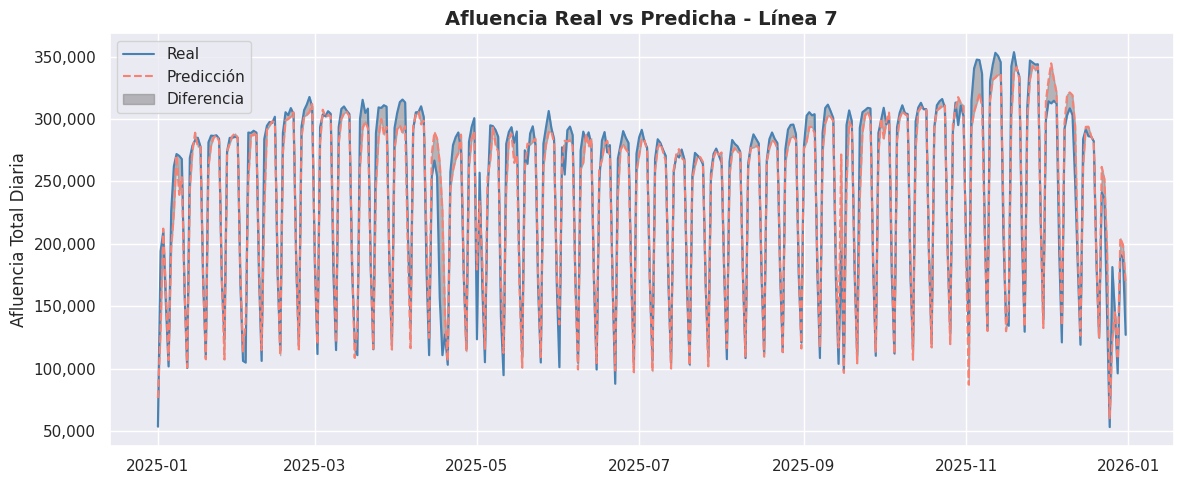

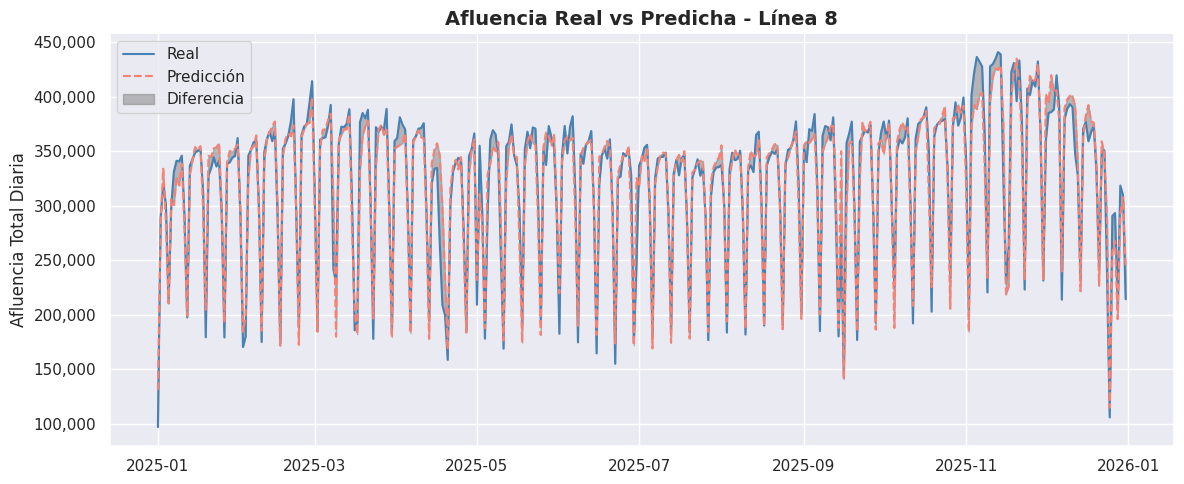

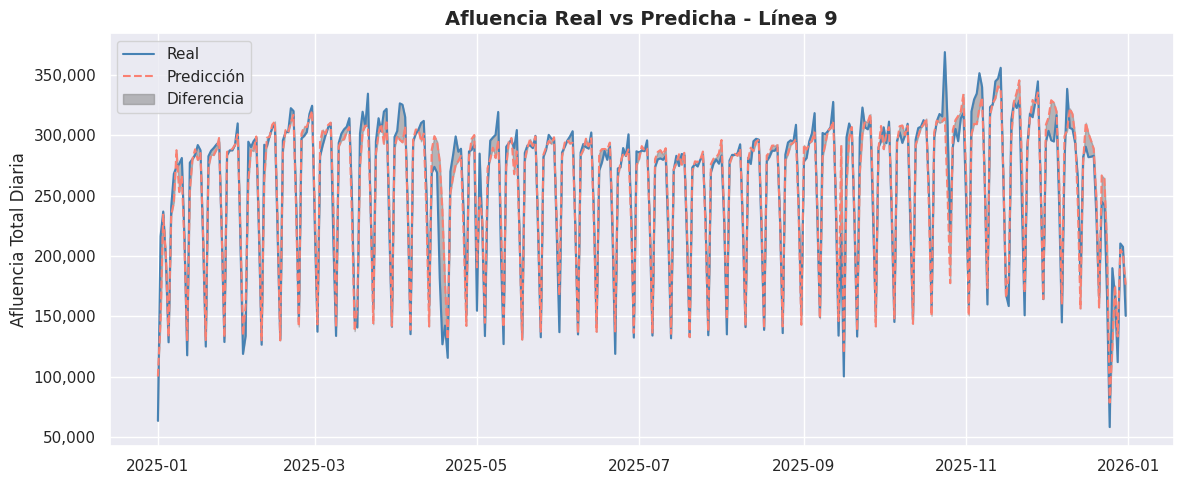

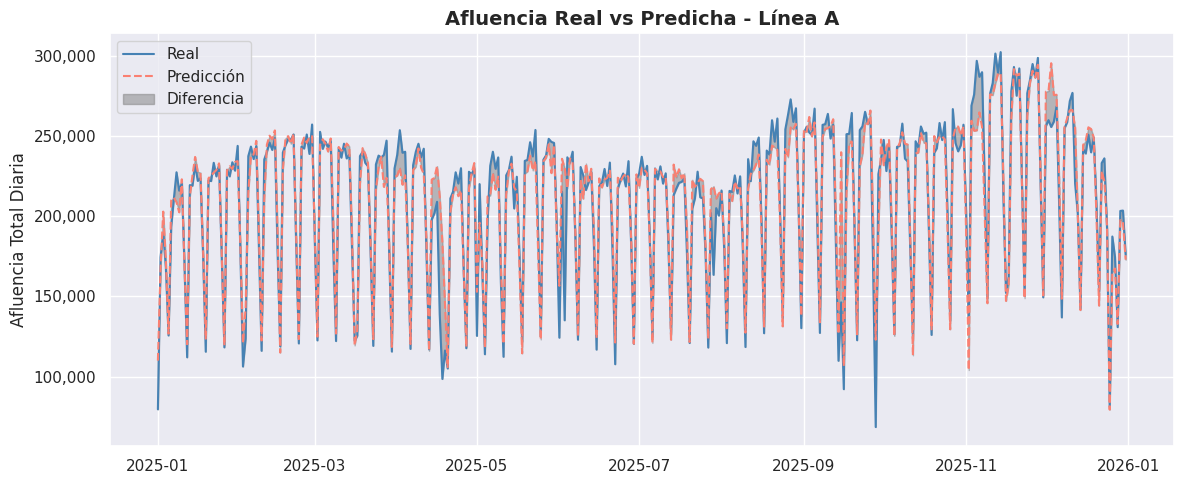

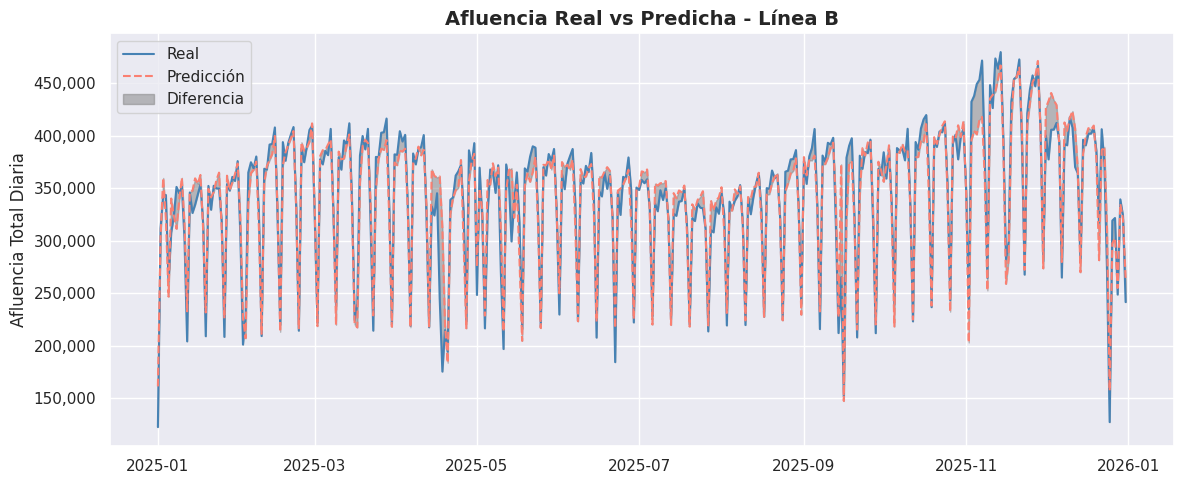

In [47]:
# Lista de lineas en orden
lineas = sorted(test_df['linea'].unique())

for linea in lineas:
    df_lineas = test_df[test_df['linea'] == linea]
    plt.figure(figsize=(12,5))
    # Afluencia Real
    plt.plot(
        df_lineas['fecha'],df_lineas['real']
        ,label='Real',color='steelblue',linewidth=1.5
    )
    plt.plot(
        df_lineas['fecha'],df_lineas['pred']
        ,label='Predicción',color='salmon',linewidth=1.5,linestyle='--'
    )
    plt.fill_between(
        df_lineas['fecha'],
        df_lineas['real'],
        df_lineas['pred'],
        alpha=0.5,color='gray',label='Diferencia'
    )
    plt.xlabel('')
    plt.ylabel('Afluencia Total Diaria')
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.title(f"Afluencia Real vs Predicha - {linea}",fontsize=14,fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()



#### Distribución de residuales

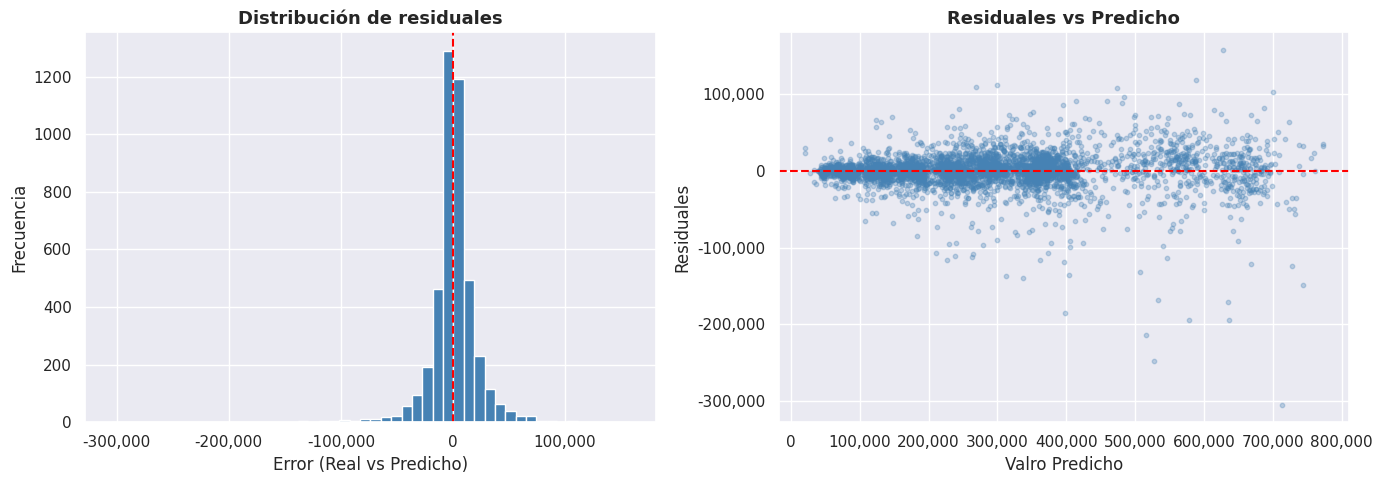

In [48]:
test_df['residual'] = test_df['real'] - test_df['pred']
fig,axes = plt.subplots(1,2,figsize=(14,5))

# Histograma
axes[0].hist(test_df['residual'],bins=50,color='steelblue',edgecolor='white')
axes[0].axvline(0,color='red',linestyle='--',linewidth=1.5)
axes[0].set_title('Distribución de residuales',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Error (Real vs Predicho)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Residuales vs Predicho
axes[1].scatter(
    test_df['pred'],test_df['residual'],alpha=0.3,s=10,color='steelblue'
)
axes[1].axhline(0,color='red',linestyle='--',linewidth=1.5)
axes[1].set_title('Residuales vs Predicho',fontsize=13,fontweight='bold')
axes[1].set_xlabel('Valro Predicho')
axes[1].set_ylabel('Residuales')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

#### Real vs Predicción


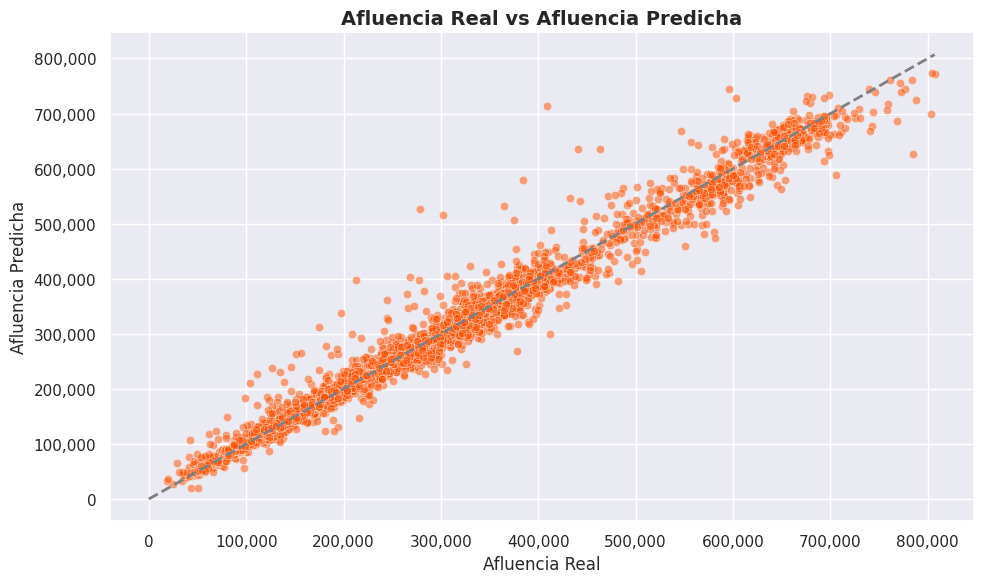

In [49]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=test_df,
    x='real',
    y='pred',
    color="#fe5000",
    alpha=0.5
)
plt.plot(
    [0, test_df['real'].max()],
     [0, test_df['real'].max()], '--', color='gray', linewidth=2
)
plt.xlabel('Afluencia Real')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.ylabel('Afluencia Predicha')
plt.title('Afluencia Real vs Afluencia Predicha',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/14_real_pred.png', dpi=150, bbox_inches='tight')
plt.show()

## Predicciones de Afluencia para 2026

### Predicciones con XGBoost

In [50]:
# Predicciones con XGBoost
historial = (
    df_modelo2[df_modelo2['fecha']<='2025-12-31']
    .sort_values(['linea','fecha'])
    [['fecha','linea','afluencia']]
    .copy()
)

# Fechas de 2026
fechas_2026 = pd.date_range('2026-01-01','2026-12-31',freq='D')
festivos_2026 = holidays.Mexico(years=2026)
lineas = df_modelo2['linea'].unique()

# Loop día a día
resultados = []
for linea in lineas:
    hist_linea = (
        historial[historial['linea'] == linea]
        .set_index('fecha')['afluencia']
        .copy()
    )
    predicciones_linea = {}
    for fecha in fechas_2026:
        def get_valor(f):
            if f in predicciones_linea:
                return predicciones_linea[f]
            elif f in hist_linea.index:
                return hist_linea[f]
            else:
                return np.nan

        # Construcción de lags
        lag1 = get_valor(fecha - pd.Timedelta(days=1))
        lag7 = get_valor(fecha - pd.Timedelta(days=7))
        lag14 = get_valor(fecha - pd.Timedelta(days=14))
        lag28 = get_valor(fecha - pd.Timedelta(days=28))

        # Rolling
        rolling7 = np.mean([get_valor(fecha - pd.Timedelta(days=i)) for i in range(1,8)])
        rolling14 = np.mean([get_valor(fecha - pd.Timedelta(days=i)) for i in range(1,15)])
        rolling30 = np.mean([get_valor(fecha - pd.Timedelta(days=i)) for i in range(1,31)])

        # Variables del calendario
        mes = fecha.month
        dia = fecha.day
        dia_semana = fecha.dayofweek
        dia_anio = fecha.dayofyear

        fila = {
            'anio': fecha.year,
            'mes' : mes,
            'dia' : dia,
            'dia_semana': dia_semana,
            'dia_anio': dia_anio,
            'es_fin_de_semana': 1 if dia_semana in [5,6] else 0,
            'es_feriado': 1 if fecha in festivos_2026 else 0,
            'mes_sin' : np.sin(2 * np.pi * mes/12),
            'mes_cos' : np.cos(2* np.pi * mes/12),
            'dia_semana_sin' : np.sin(2 * np.pi * dia_semana/7),
            'dia_semana_cos' : np.cos(2 * np.pi * dia_semana/7),
            'dia_sin' : np.sin(2 * np.pi * dia/31),
            'dia_cos' : np.cos(2 * np.pi *dia/31),
            'lag1' : lag1,
            'lag7' : lag7,
            'lag14' : lag14,
            'lag28' : lag28,
            'rolling7' : rolling7,
            'rolling14' : rolling14,
            'rolling30' : rolling30,

            # Dummies de línea
            **{f'linea_{l}': int(l == linea) for l in lineas}
        }

        # Predecir
        X_pred = pd.DataFrame([fila])[X_train_2.columns]
        pred = model2.predict(X_pred)[0]

        if linea == 'Línea 1' and fecha == pd.Timestamp('2026-01-01'):
            print(f"lag1:     {lag1:,.0f}")
            print(f"lag7:     {lag7:,.0f}")
            print(f"lag14:    {lag14:,.0f}")
            print(f"lag28:    {lag28:,.0f}")
            print(f"rolling7: {rolling7:,.0f}")
            print(f"pred:     {pred:,.0f}")

        predicciones_linea[fecha] = pred
        resultados.append({
            'fecha' : fecha,
            'linea' : linea,
            'pred' : pred
        })
df_2026 = pd.DataFrame(resultados)
print(df_2026.head(12))

lag1:     319,037
lag7:     133,072
lag14:    485,765
lag28:    490,808
rolling7: 349,488
pred:     184,002
        fecha    linea          pred
0  2026-01-01  Línea 1  184002.37500
1  2026-01-02  Línea 1  400498.21875
2  2026-01-03  Línea 1  391994.96875
3  2026-01-04  Línea 1  313460.78125
4  2026-01-05  Línea 1  453575.71875
5  2026-01-06  Línea 1  412289.59375
6  2026-01-07  Línea 1  417196.15625
7  2026-01-08  Línea 1  403689.21875
8  2026-01-09  Línea 1  405931.62500
9  2026-01-10  Línea 1  376297.56250
10 2026-01-11  Línea 1  284353.18750
11 2026-01-12  Línea 1  423154.40625


#### Visualización de las Predicciones

##### Afluencia Diaria

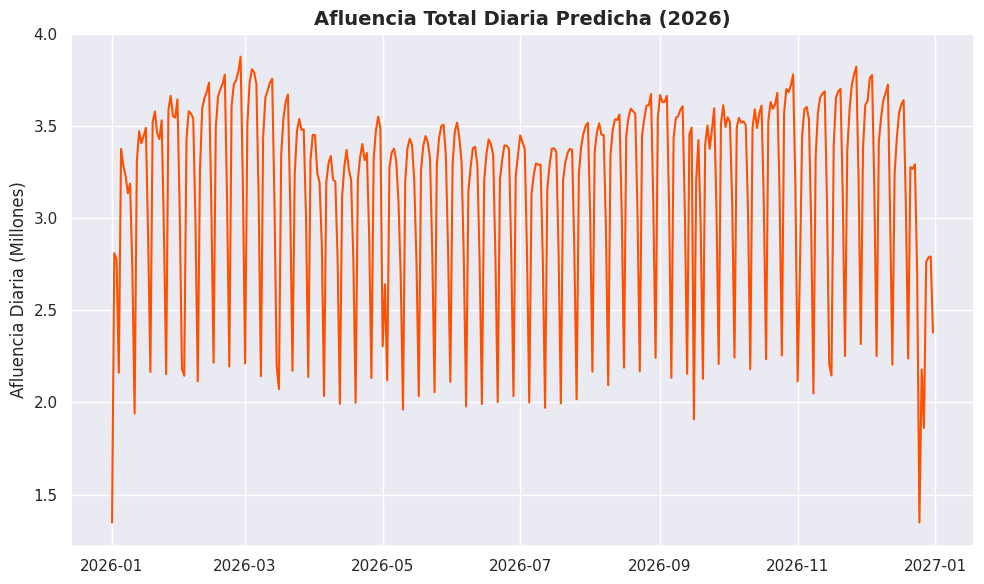

In [51]:
diario_pred = (
    df_2026
    .groupby('fecha')['pred']
    .sum()
    .reset_index()
    .sort_values('fecha')
)
diario_pred['pred_mill'] = diario_pred['pred']/1e6
plt.figure(figsize=(10,6))
sns.lineplot(
    data=diario_pred,
    x='fecha',
    y='pred_mill',
    color=metro_color
)
plt.xlabel('')
plt.ylabel('Afluencia Diaria (Millones)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))
plt.title('Afluencia Total Diaria Predicha (2026)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/15_afluencia_pred.png', dpi=150, bbox_inches='tight')
plt.show()

##### Afluencia Total por Línea


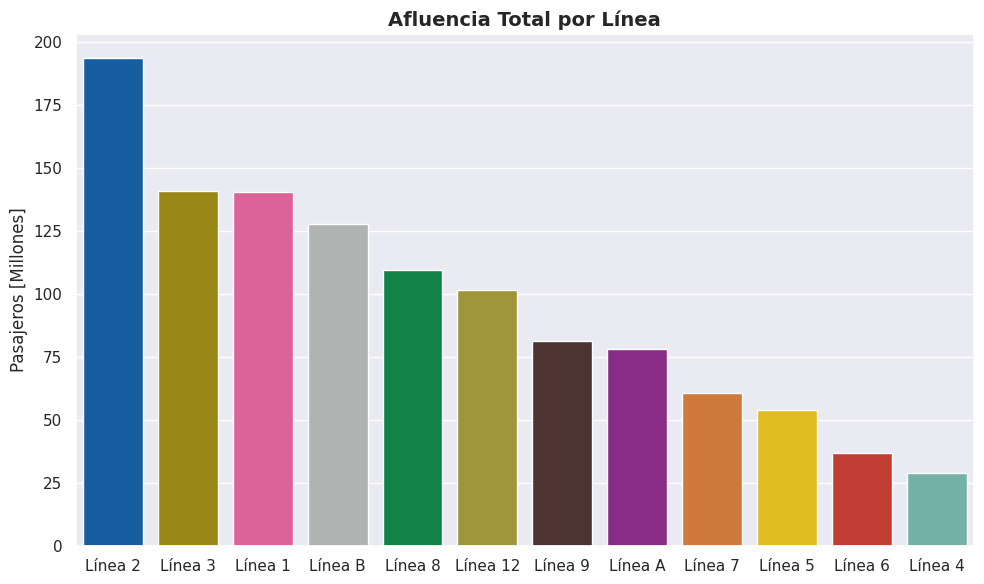

In [52]:
linea_pred = (
    df_2026
    .groupby('linea')['pred']
    .sum()
    .reset_index()
    .sort_values(by='pred',ascending=False)
)
linea_pred['pred_mill'] = linea_pred['pred']/1e6

linea_pred.sort_values('pred_mill',ascending=True)
plt.figure(figsize=(10,6))
sns.barplot(
    data=linea_pred,
    x='linea',
    y='pred_mill',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('')
plt.ylabel('Pasajeros [Millones]')
plt.title('Afluencia Total por Línea',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/16_afluencia_linea.png', dpi=150, bbox_inches='tight')
plt.show()

##### Afluencia Mensual Predicha

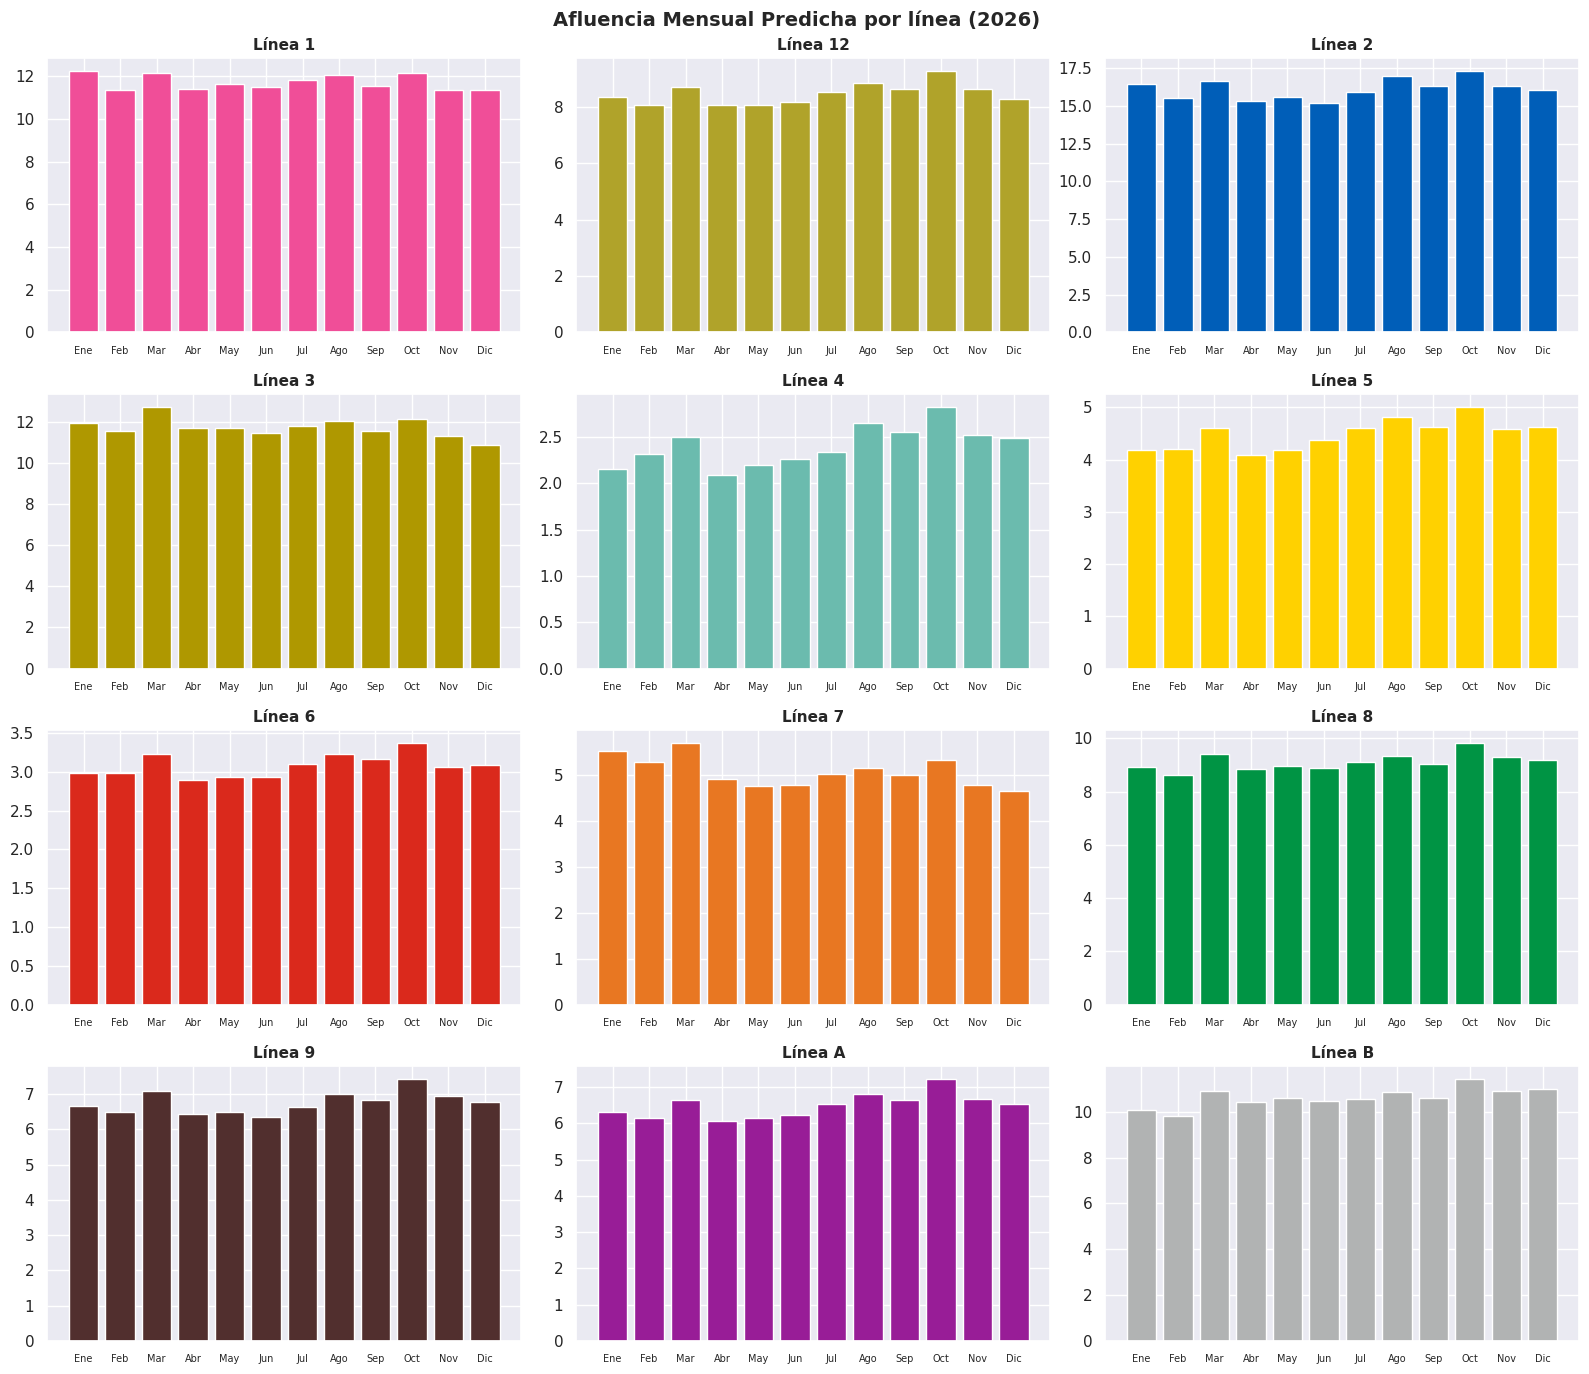

In [53]:
mensual_2026 = (
    df_2026
    .groupby(['linea',df_2026['fecha'].dt.month])['pred']
    .sum()
    .reset_index()
    .rename(columns={'fecha':'mes'})
)
mensual_2026['pred_mill'] = mensual_2026['pred']/1e6

# Orden de los meses
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']
lineas_unicas = sorted(df_2026['linea'].unique())
ncols = 3
nrows = int(np.ceil(len(lineas_unicas)/ncols))

fig,axes = plt.subplots(nrows,ncols,figsize=(16,nrows*3.5),sharey=False)
axes = axes.flatten()

for i,linea in enumerate(lineas_unicas):
    ax = axes[i]
    datos = mensual_2026[mensual_2026['linea'] == linea]
    ax.bar(range(1,13),datos['pred_mill'],color=colores_metro[linea])
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(orden_meses,fontsize=7)
    ax.set_title(linea,fontsize=11,fontweight='bold')

plt.suptitle('Afluencia Mensual Predicha por línea (2026)',fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/17_mes_linea_pred.png', dpi=150, bbox_inches='tight')
plt.show()

### Prophet

In [54]:
# Encoder a df_modelo2
df_modelo2_encoded = encoder.transform(df_modelo2[['linea']])
df_modelo2_encoded = pd.DataFrame(
    df_modelo2_encoded,
    columns=columnas,
    index=df_modelo2.index
)

df_modelo2_full = pd.concat([df_modelo2.drop(columns=['linea']),
                             df_modelo2_encoded],axis=1)
df_modelo2_full.head()

,fecha,afluencia,anio,mes,dia,dia_semana,dia_anio,es_fin_de_semana,afluencia_log,es_feriado,...,linea_Línea 2,linea_Línea 3,linea_Línea 4,linea_Línea 5,linea_Línea 6,linea_Línea 7,linea_Línea 8,linea_Línea 9,linea_Línea A,linea_Línea B
0,2010-01-01,251474,2010,1,1,4,1,0,12.435099,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,2010-01-02,511103,2010,1,2,5,2,1,13.144328,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24,2010-01-03,423407,2010,1,3,6,3,1,12.956092,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36,2010-01-04,769747,2010,1,4,0,4,0,13.553818,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,2010-01-05,733953,2010,1,5,1,5,0,13.506202,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Preparación para utilizar Prophet

In [55]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# Festivos de México en 2025 y 2026
festivos = holidays.Mexico(years=[2025,2026])

# Dataframe con formato para Prophet
# ds =  fecha, y = afluencia
df_prophet = (
    df_modelo2
    .groupby('fecha')['afluencia']
    .sum().reset_index()
    .rename(columns={'fecha':'ds','afluencia':'y'})
    .sort_values('ds')
)
print(df_prophet.head())
print(f"\n Rango de fechas:{df_prophet['ds'].min()} - {df_prophet['ds'].max()}")
print(f"Total de días: {len(df_prophet)}")

          ds        y
0 2010-01-01  1511363
1 2010-01-02  2633052
2 2010-01-03  2216448
3 2010-01-04  4085108
4 2010-01-05  4164143

 Rango de fechas:2010-01-01 00:00:00 - 2025-12-31 00:00:00
Total de días: 5844


#### Utilizando Predicciones de XGBoost

In [56]:
pred_xgb_historico = (
    df_modelo2_full
    .assign(
        pred_xgb = model2.predict(df_modelo2_full[X_train_2.columns])
    )
    .groupby('fecha')['pred_xgb'].sum().reset_index()
    .rename(columns={'fecha':'ds'})
)
pred_xgb_2026 = (
    df_2026
    .groupby('fecha')['pred']
    .sum()
    .reset_index()
    .rename(columns={'fecha':'ds','pred':'pred_xgb'})
)

# Merge de predicciones históricas con el DF de prophet
df_prophet = df_prophet.merge(pred_xgb_historico,on='ds',how='left')

print(f"y                   :{df_prophet['y'].mean():,.0f}")
print(f"pred_xgb_historico  :{df_prophet['pred_xgb'].mean():,.0f}")
print(f"pred_xgb_2026       :{pred_xgb_2026['pred_xgb'].mean():,.0f}")


y                   :3,839,562
pred_xgb_historico  :3,838,629
pred_xgb_2026       :3,158,811


### Entrenamiento con Prophet

In [57]:
from datetime import date
# Dataframe de días festivos con el formato de Prophet
festivos_df = pd.DataFrame({
    'ds': pd.to_datetime(list(festivos.keys())),
    'holiday' : list(festivos.values())
})

# 2025 se usará para evaluación
fecha_corte = pd.Timestamp('2024-11-30')
fecha_fin   = pd.Timestamp('2026-12-31')
dias_necesarios = (fecha_fin - fecha_corte).days

df_prophet_train = df_prophet[df_prophet['ds'] <= fecha_corte].copy()

# Definición del modelo

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=festivos_df,
    seasonality_mode='multiplicative',
    interval_width=0.95
)

# Agregando predicciones de XGBboost como regresor adicional
m.add_regressor('pred_xgb')

# Entrenamiento
m.fit(df_prophet_train)

### Predicciones para 2026

In [58]:
# Dataframe: afluencia histórica + 2026
futuro = m.make_future_dataframe(periods=dias_necesarios,freq='D')

# Agregando predicciones de xgb al DF
pred_xgb_completo = pd.concat([
    pred_xgb_historico[['ds','pred_xgb']],
    pred_xgb_2026[['ds','pred_xgb']]
]).drop_duplicates('ds')

futuro = futuro.merge(pred_xgb_completo,on='ds',how='left')

# Predicciones
forecast = m.predict(futuro)

# Resultados: yhat = predicción, yhat_lower y yhat_upper = intervalo de confianza
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].head(12))

           ds          yhat    yhat_lower    yhat_upper
0  2010-01-01  1.475345e+06  1.059230e+06  1.924134e+06
1  2010-01-02  2.314644e+06  1.870789e+06  2.763554e+06
2  2010-01-03  2.344389e+06  1.896578e+06  2.800008e+06
3  2010-01-04  4.011296e+06  3.574276e+06  4.492844e+06
4  2010-01-05  4.329992e+06  3.896267e+06  4.761688e+06
5  2010-01-06  3.773826e+06  3.338880e+06  4.238249e+06
6  2010-01-07  4.030597e+06  3.582147e+06  4.492102e+06
7  2010-01-08  4.028201e+06  3.589902e+06  4.469022e+06
8  2010-01-09  3.139861e+06  2.686579e+06  3.582447e+06
9  2010-01-10  2.138229e+06  1.708664e+06  2.624385e+06
10 2010-01-11  4.155474e+06  3.709919e+06  4.588993e+06
11 2010-01-12  4.102602e+06  3.671264e+06  4.533644e+06


In [59]:
print(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(12))

             ds          yhat    yhat_lower    yhat_upper
6197 2026-12-20  2.223790e+06  1.758336e+06  2.677681e+06
6198 2026-12-21  3.243112e+06  2.808153e+06  3.687019e+06
6199 2026-12-22  3.228088e+06  2.784347e+06  3.644087e+06
6200 2026-12-23  3.258488e+06  2.796267e+06  3.669747e+06
6201 2026-12-24  2.637862e+06  2.177262e+06  3.052071e+06
6202 2026-12-25  1.257338e+06  8.185127e+05  1.687237e+06
6203 2026-12-26  2.133362e+06  1.735711e+06  2.582558e+06
6204 2026-12-27  1.851276e+06  1.384927e+06  2.305796e+06
6205 2026-12-28  2.726121e+06  2.281320e+06  3.164434e+06
6206 2026-12-29  2.744422e+06  2.298503e+06  3.210819e+06
6207 2026-12-30  2.751511e+06  2.297023e+06  3.210067e+06
6208 2026-12-31  2.315278e+06  1.846978e+06  2.779172e+06


### Evaluación

In [60]:
# Valores reales de 2025
real_2025 = (
    df_modelo2[df_modelo2['fecha'].dt.year == 2025]
    .groupby('fecha')['afluencia']
    .sum()
    .reset_index()
    .rename(columns={'fecha':'ds'})
)

# Predicciones de prophet para 2025
pred_prophet_2025 = (
    forecast[forecast['ds'].dt.year == 2025]
    [['ds','yhat','yhat_lower','yhat_upper']]
    .copy()
)

# Merge
eval_2025 = real_2025.merge(pred_prophet_2025,on='ds')

# Evaluacion
mae = mean_absolute_error(eval_2025['afluencia'],eval_2025['yhat'])
rmse = np.sqrt(mean_squared_error(eval_2025['afluencia'],eval_2025['yhat']))
r2 = r2_score(eval_2025['afluencia'],eval_2025['yhat'])
print("── Evaluación Prophet en 2025 ──────────────────────")
print(f"MAE:  {mae:12,.0f}")
print(f"RMSE: {rmse:12,.0f}")
print(f"R²:   {r2:>12.3f}")


# Comparación de modelos
print("\n── Comparación de modelos ────────────────────")
print(f"{'Modelo':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print(f"{'XGBoost modelo 2':<25} {'13,382':>12} {'22,644':>12} {'0.982':>8}")
print(f"{'Prophet + XGBoost':<25} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.3f}")

── Evaluación Prophet en 2025 ──────────────────────
MAE:       119,069
RMSE:      190,716
R²:          0.942

── Comparación de modelos ────────────────────
Modelo                             MAE         RMSE       R²
XGBoost modelo 2                13,382       22,644    0.982
Prophet + XGBoost              119,069      190,716    0.942


El modelo XGBoost, *modelo 2*, hace predicciones por línea. En cambio, **Prophet** predice el total del sistema, de las 12 líneas juntas. Por lo cual, se tiene que hacer una comparación justa.
Hay dos opciones
1. Hacer un modelo de Prophet por línea.
2. Agregar las predicciones de XGBoost sumando las 12 líneas por día.

La segunda opción se utilizará para comparar el error

In [61]:
# XGBoost en 2025 a nivel sistema para comparación justa
pred_xgb_2025 = (
    pred_xgb_historico[pred_xgb_historico['ds'].dt.year == 2025]
    .rename(columns={'pred_xgb': 'yhat_xgb'})
)

eval_2025 = eval_2025.merge(pred_xgb_2025, on='ds')

mae_xgb  = mean_absolute_error(eval_2025['afluencia'], eval_2025['yhat_xgb'])
rmse_xgb = np.sqrt(mean_squared_error(eval_2025['afluencia'], eval_2025['yhat_xgb']))
r2_xgb   = r2_score(eval_2025['afluencia'], eval_2025['yhat_xgb'])

print("\n── Comparación justa (nivel sistema) ───────────────")
print(f"{'Modelo':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print(f"{'XGBoost modelo 2':<25} {mae_xgb:>12,.0f} {rmse_xgb:>12,.0f} {r2_xgb:>8.3f}")
print(f"{'Prophet + XGBoost':<25} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.3f}")


── Comparación justa (nivel sistema) ───────────────
Modelo                             MAE         RMSE       R²
XGBoost modelo 2               121,562      192,510    0.941
Prophet + XGBoost              119,069      190,716    0.942


### Visualizaciones

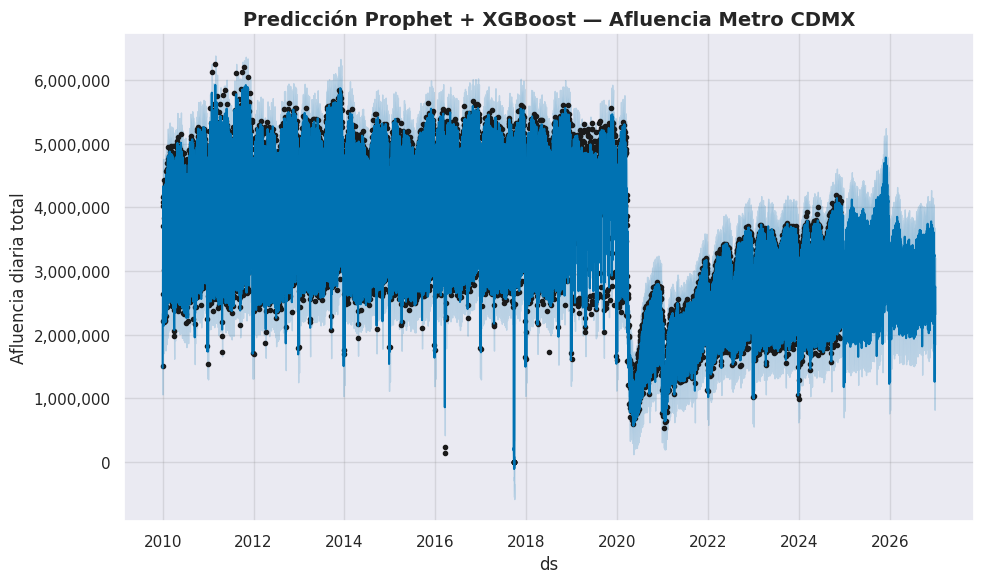

In [62]:
fig1 = m.plot(forecast)
plt.title('Predicción Prophet + XGBoost — Afluencia Metro CDMX',
          fontsize=14, fontweight='bold')
plt.ylabel('Afluencia diaria total')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

#### Predicción para 2026

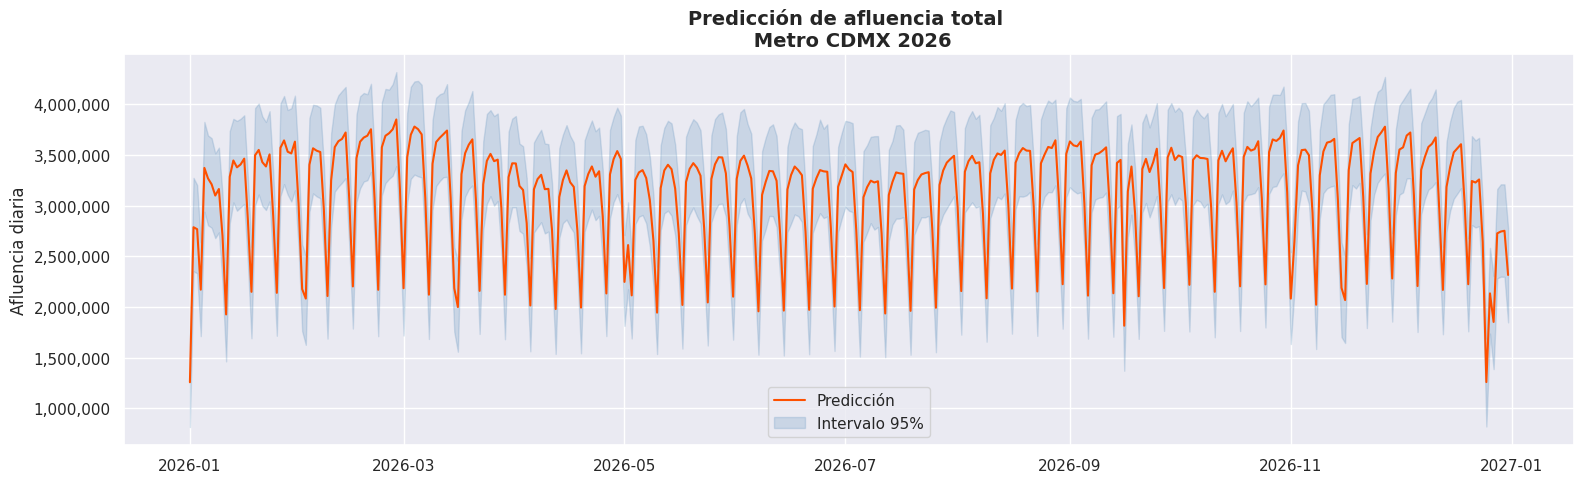

In [85]:
pred_2026 = forecast[forecast['ds'].dt.year == 2026].copy()

pred_2026['pred_afluencia'] = pred_2026['yhat']
pred_2026['pred_afluencia_lower'] = pred_2026['yhat_lower']
pred_2026['pred_afluencia_upper'] = pred_2026['yhat_upper']

# Visualización
plt.figure(figsize=(16, 5))
plt.plot(pred_2026['ds'], pred_2026['pred_afluencia'],
         color=metro_color, linewidth=1.5, label='Predicción')
plt.fill_between(pred_2026['ds'],
                 pred_2026['pred_afluencia_lower'],
                 pred_2026['pred_afluencia_upper'],
                 alpha=0.2, color='steelblue', label='Intervalo 95%')
plt.xlabel('')
plt.ylabel('Afluencia diaria')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.title('Predicción de afluencia total \n Metro CDMX 2026',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('/content/visualizaciones/18_afluencia_2026.png', dpi=150, bbox_inches='tight')
plt.show()

#### Afluencia 2025 + Predicción 2026

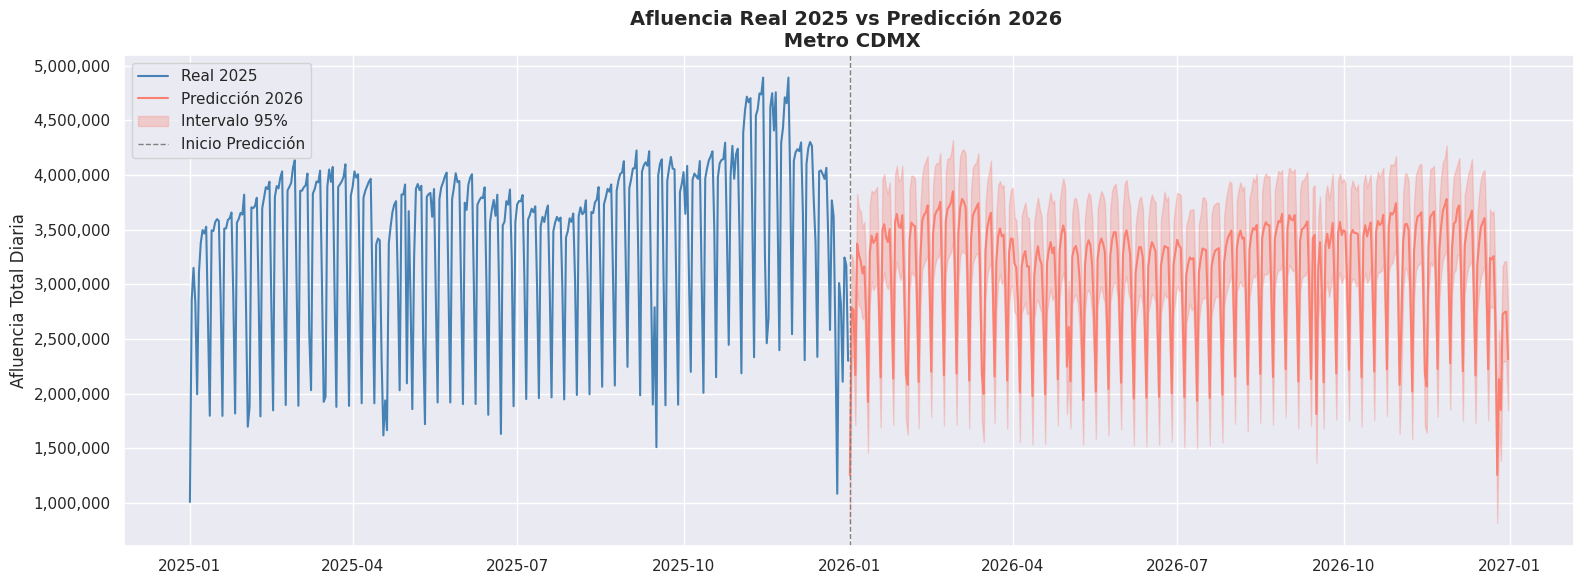

In [64]:
# Afluencia
fig, ax = plt.subplots(figsize=(16, 6))

# Real 2025
ax.plot(
    real_2025['ds'],real_2025['afluencia'], color='steelblue',
    linewidth=1.5, label='Real 2025'
)

# Preddición 2026
ax.plot(
    pred_2026['ds'],pred_2026['yhat'],color='salmon',linewidth=1.5,
    label='Predicción 2026'
)

# Intervalo de confianza
ax.fill_between(
    pred_2026['ds'],
    pred_2026['yhat_lower'],
    pred_2026['yhat_upper'],
    alpha=0.3, color='salmon', label='Intervalo 95%'
)

# Línea divisoria entre 2025 y 2026
ax.axvline(pd.Timestamp('2026-01-01'),color='gray',linestyle='--',linewidth=1,
           label='Inicio Predicción')
ax.set_xlabel('')
ax.set_ylabel('Afluencia Total Diaria')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Afluencia Real 2025 vs Predicción 2026 \n Metro CDMX',fontsize=14,
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/content/visualizaciones/19_real_pred.png', dpi=150, bbox_inches='tight')
plt.show()

#### Predicción Mensual

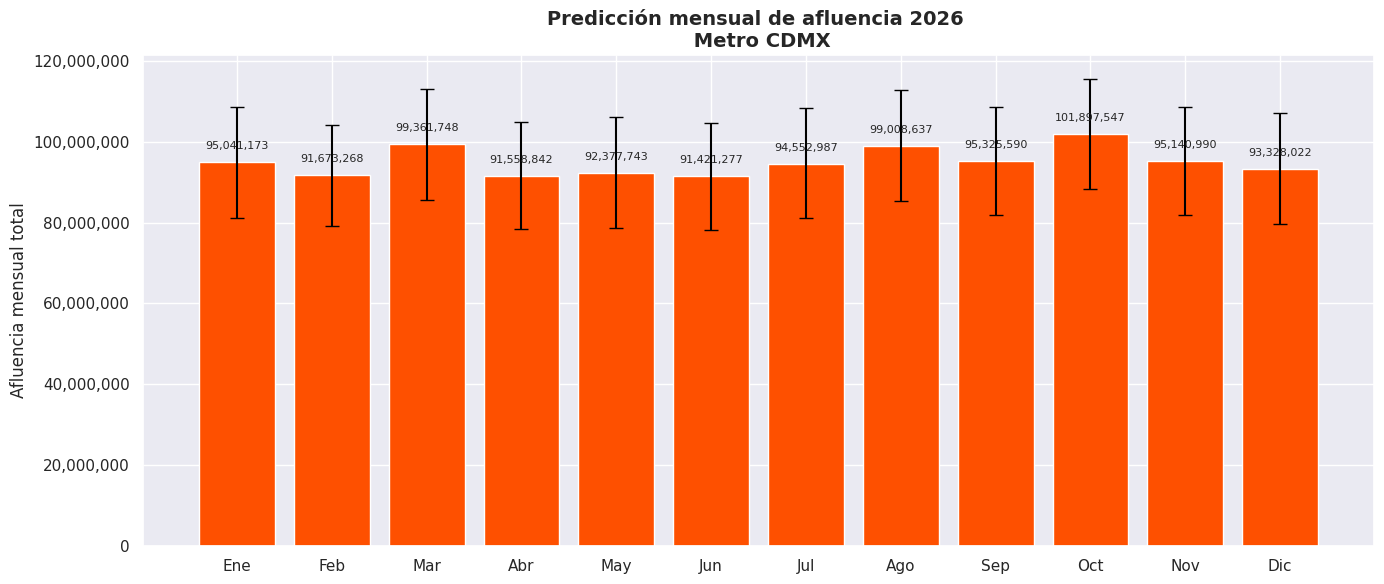

In [84]:
mensual_2026 = (
    pred_2026
    .groupby(pred_2026['ds'].dt.month)
    .agg(
        yhat = ('yhat','sum'),
        yhat_lower = ('yhat_lower','sum'),
        yhat_upper = ('yhat_upper','sum')
    )
    .reset_index()
    .rename(columns={'ds':'mes'})
)

# Orden Meses
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

mensual_2026['mes_nom'] = orden_meses

# Visualización
fig,ax = plt.subplots(figsize=(14,6))
bars = ax.bar(
    mensual_2026['mes_nom'],mensual_2026['yhat'],
    color=metro_color
)

# Intervalo de confianza
ax.errorbar(
    mensual_2026['mes_nom'],
    mensual_2026['yhat'],
    yerr= [
        mensual_2026['yhat'] - mensual_2026['yhat_lower'],
        mensual_2026['yhat_upper'] - mensual_2026['yhat']
    ],
    fmt='none',color='black',capsize=5,linewidth=1.5,zorder=3
)
ax.bar_label(bars, fmt='{:,.0f}', padding=8, fontsize=8)
ax.set_xlabel('')
ax.set_ylabel('Afluencia mensual total')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Predicción mensual de afluencia 2026 \n Metro CDMX',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/visualizaciones/20_afluencia_mes.png', dpi=150, bbox_inches='tight')
plt.show()

#### Componentes del modelo

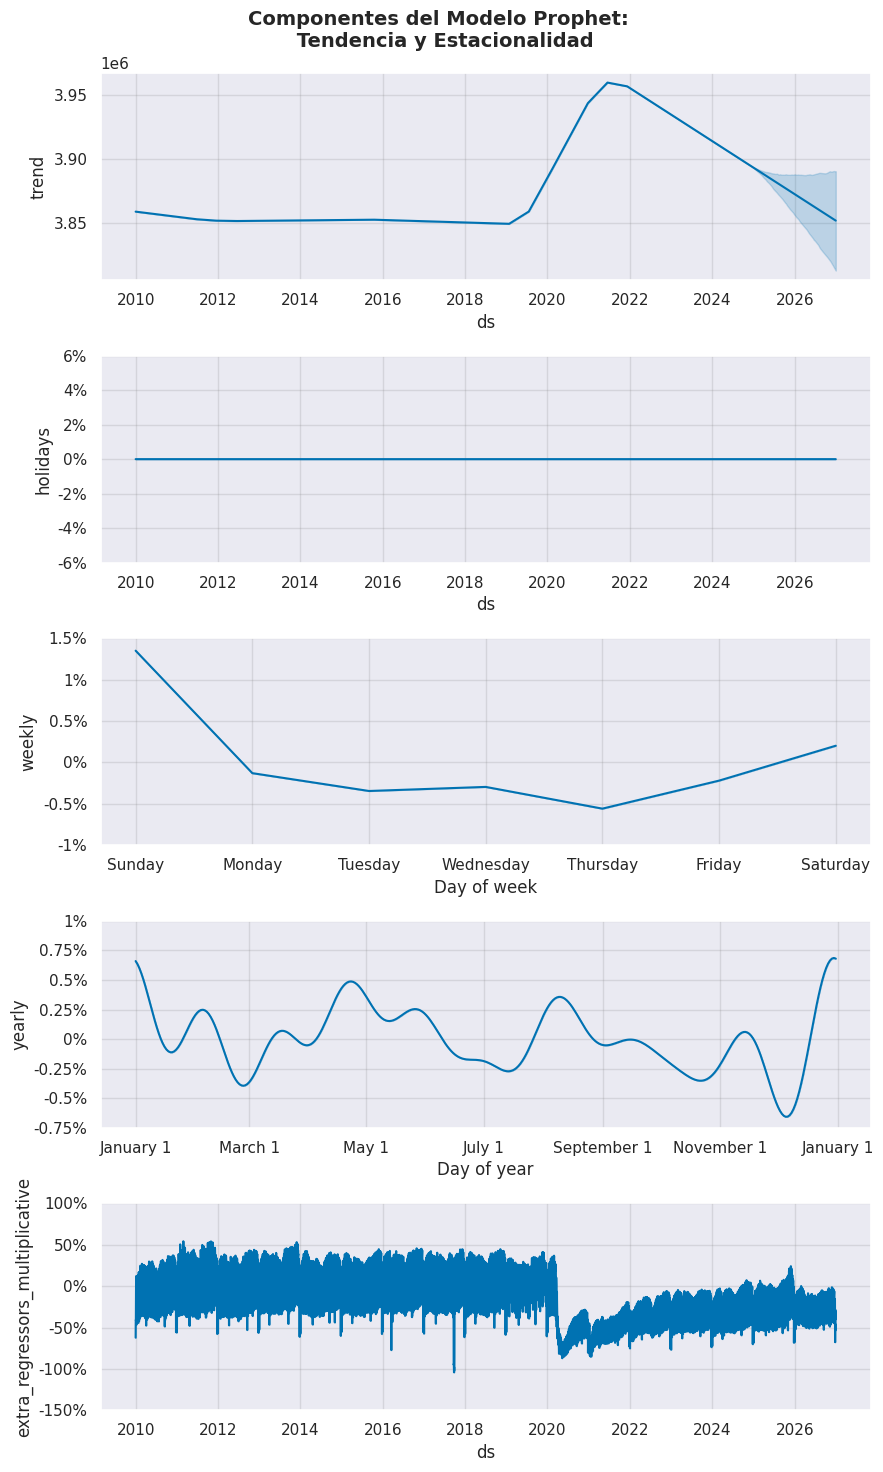

In [66]:
fig3 = m.plot_components(forecast)
plt.suptitle('Componentes del Modelo Prophet: \n Tendencia y Estacionalidad',
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

## Predicciones para cada línea con Prophet

In [67]:
modelos_prophet = {}
forecasts_prophet = {}
lineas = df_modelo2['linea'].unique()

for linea in lineas:
    print(f"Entrenando Prophet para {linea}...")

    # Datos históricas de las lineas
    df_linea = (
        df_modelo2[df_modelo2['linea'] == linea]
        .groupby('fecha')['afluencia']
        .sum()
        .reset_index()
        .rename(columns={'fecha':'ds','afluencia':'y'})
        .sort_values('ds')
    )

    # Predicciones Históricas de XGBoost para las lineas
    mask = df_modelo2['linea'] == linea
    pred_hist_linea = (
        df_modelo2_full[mask]
        .assign(pred_xgb=model2.predict(df_modelo2_full[mask][X_train_2.columns]))
        [['fecha','pred_xgb']]
        .rename(columns={'fecha':'ds'})
    )

    # Predicciones XGBoost para 2026
    pred_2026_linea = (
        df_2026[df_2026['linea'] == linea]
        [['fecha','pred']]
        .rename(columns={'fecha':'ds','pred':'pred_xgb'})
    )

    # Merge
    df_linea = df_linea.merge(pred_hist_linea,on='ds',how='left')

    # Entrenar hasta Nov 2024
    df_linea_train = df_linea[df_linea['ds'] <= '2024-11-30'].copy()


    # Modelo
    m_linea = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=festivos_df,
        seasonality_mode='multiplicative',
        interval_width=0.95
    )
    m_linea.add_regressor('pred_xgb')
    m_linea.fit(df_linea_train)

    # Dataframe
    dias_necesarios = (pd.Timestamp('2026-12-31')-pd.Timestamp('2024-11-30')).days
    futuro = m_linea.make_future_dataframe(periods=dias_necesarios,freq='D')

    pred_xgb_completo = pd.concat([
        pred_hist_linea[['ds','pred_xgb']],
        pred_2026_linea[['ds','pred_xgb']]
    ]).drop_duplicates('ds').sort_values('ds')

    futuro = futuro.merge(pred_xgb_completo,on='ds',how='left')

    # Predicción
    forecast_linea = m_linea.predict(futuro)

    # Guardar predicciones
    modelos_prophet[linea] = m_linea
    forecasts_prophet[linea] = forecast_linea

print('Modelos Entrenados para todas las líneas')

Entrenando Prophet para Línea 1...
Entrenando Prophet para Línea 12...
Entrenando Prophet para Línea 2...
Entrenando Prophet para Línea 3...
Entrenando Prophet para Línea 4...
Entrenando Prophet para Línea 5...
Entrenando Prophet para Línea 6...
Entrenando Prophet para Línea 7...
Entrenando Prophet para Línea 8...
Entrenando Prophet para Línea 9...
Entrenando Prophet para Línea A...
Entrenando Prophet para Línea B...
Modelos Entrenados para todas las líneas


### Visualizaciones

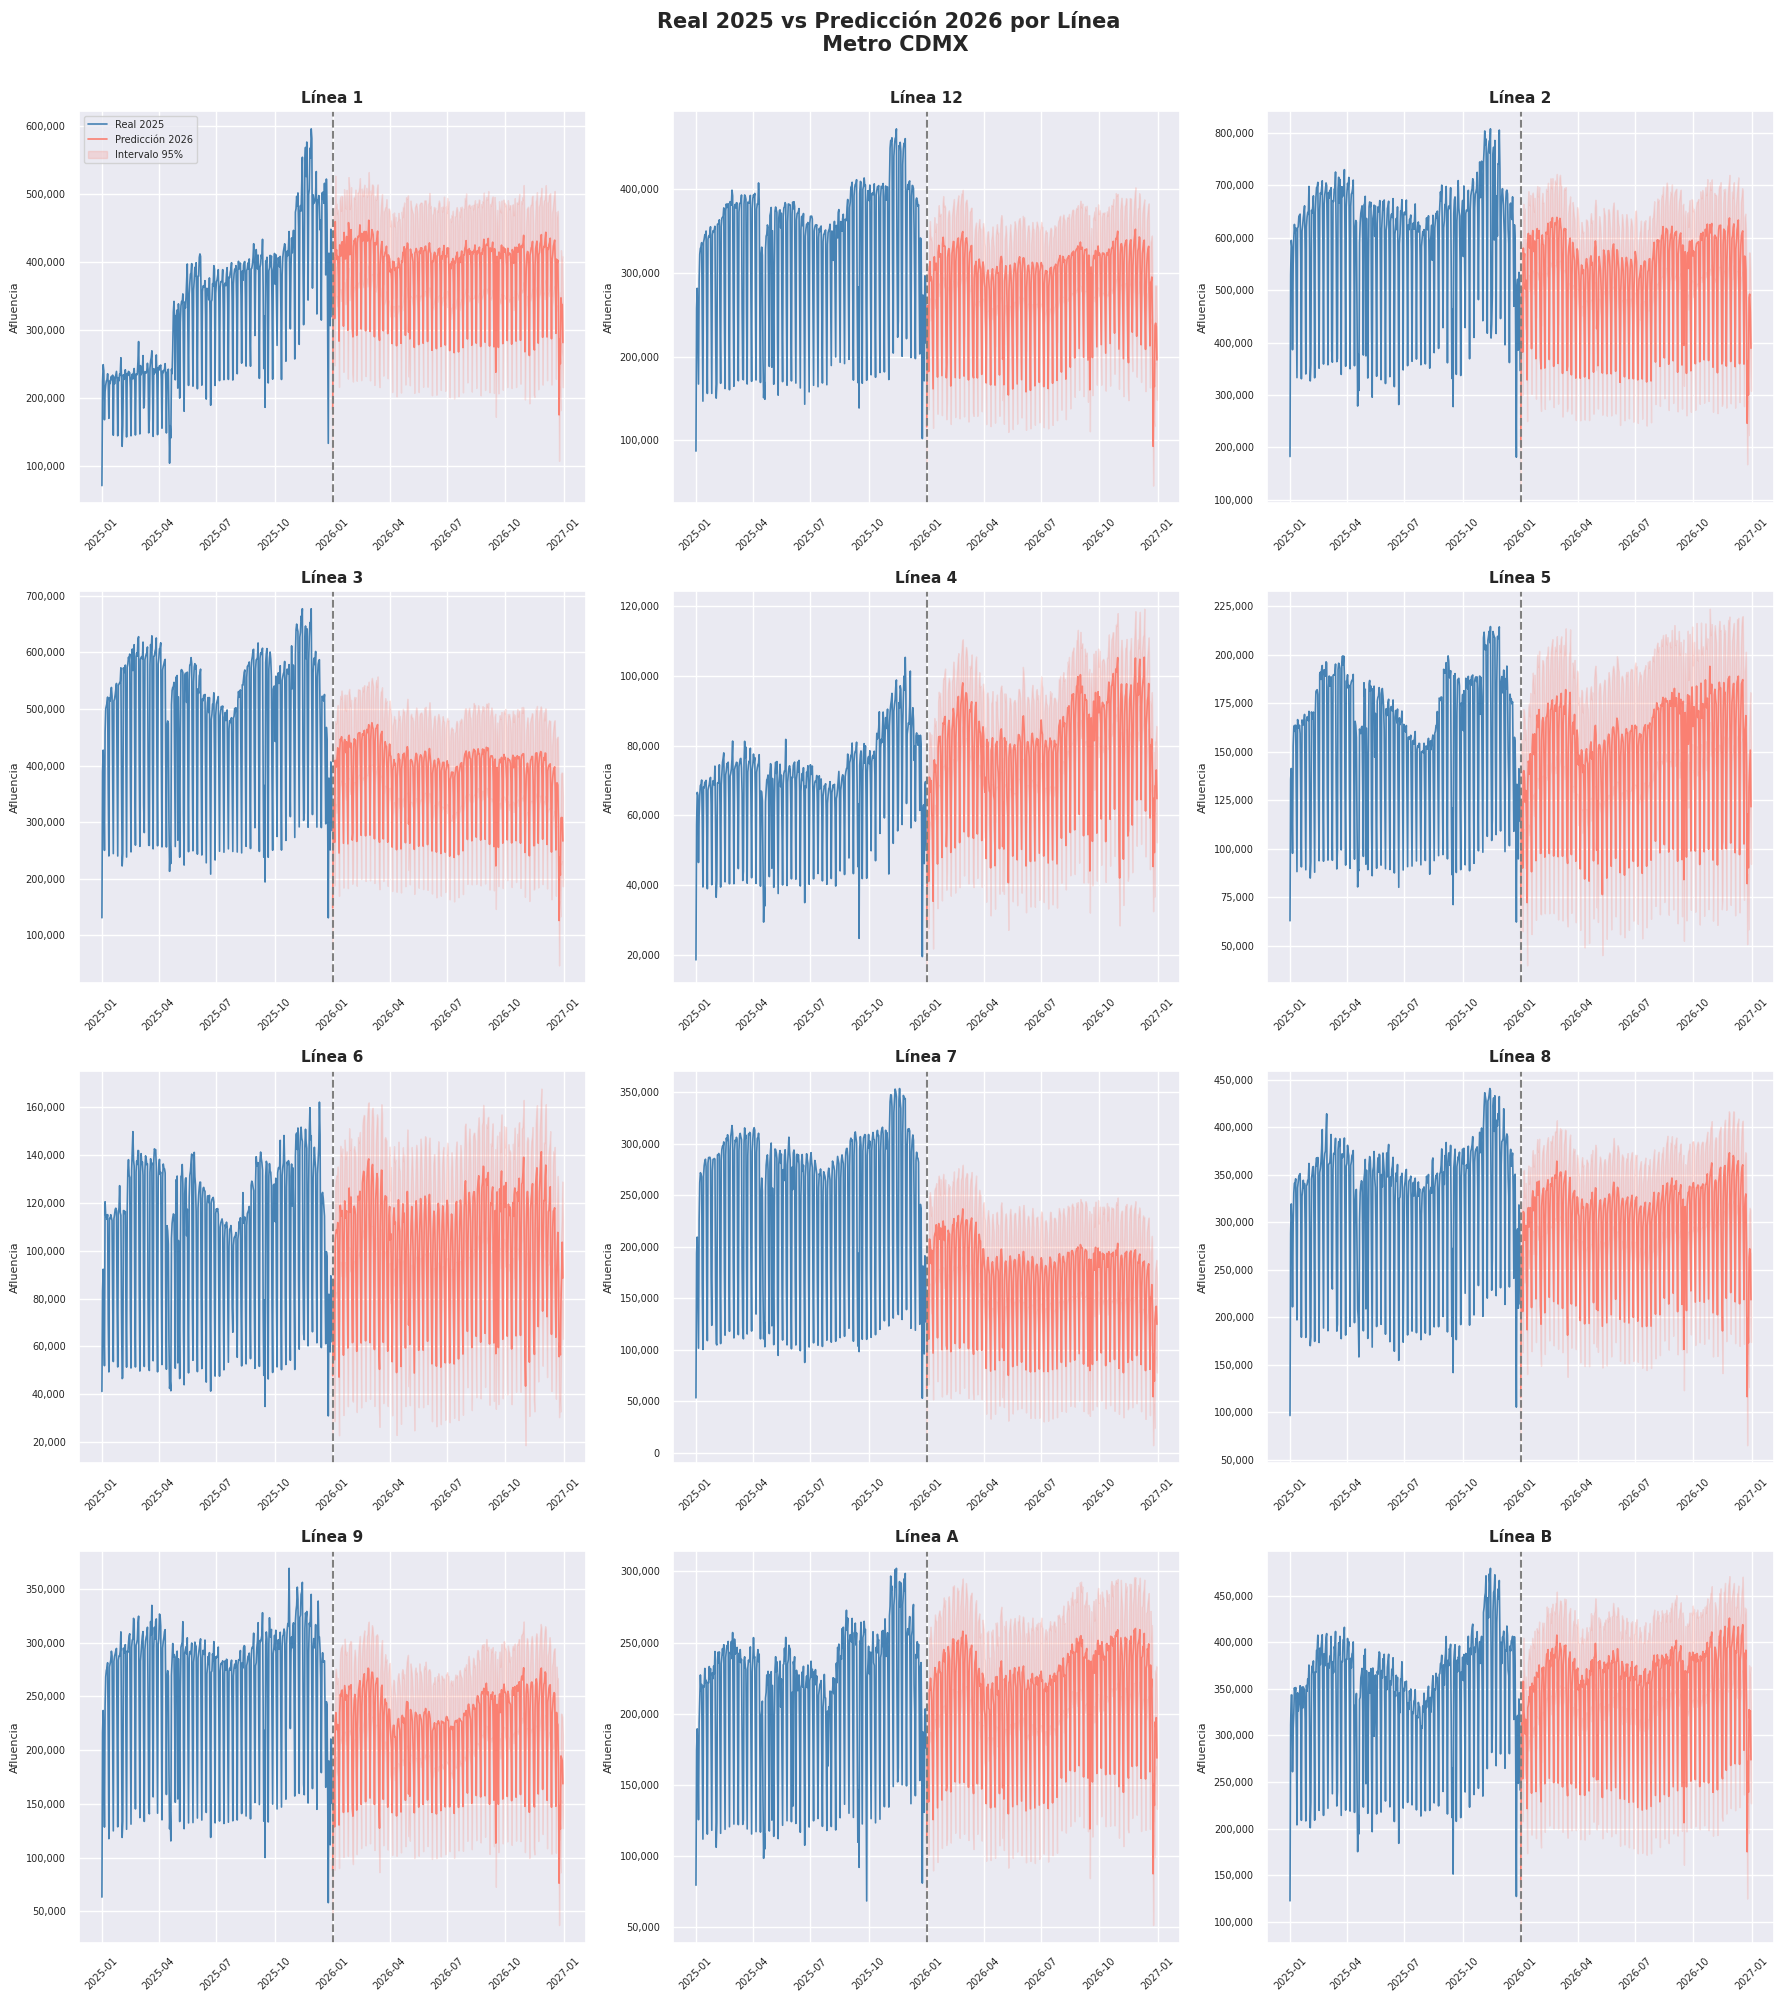

In [68]:
fig,axes = plt.subplots(4,3,figsize=(18,20),sharey=False)
axes = axes.flatten()

for i,linea in enumerate(sorted(forecasts_prophet.keys())):
    ax = axes[i]
    forecast_linea = forecasts_prophet[linea]

    # Datos de 2025
    real_2025 = (
        df_modelo2[(df_modelo2['linea'] == linea) & (df_modelo2['fecha'].dt.year == 2025)]
        .groupby('fecha')['afluencia']
        .sum()
        .reset_index()
    )

    # Predicción para 2026
    pred_linea = forecast_linea[forecast_linea['ds'].dt.year == 2026].copy()

    # Real 2025
    ax.plot(
        real_2025['fecha'],real_2025['afluencia'],
        color='steelblue',linewidth=1.2,label='Real 2025'
    )

    # Predicción 2026
    ax.plot(
        pred_linea['ds'],pred_linea['yhat'],
        color='salmon',linewidth=1.2,label='Predicción 2026'
    )

    # Intervalo de confianza
    ax.fill_between(
        pred_linea['ds'],
        pred_linea['yhat_lower'],
        pred_linea['yhat_upper'],
        alpha=0.2,color='salmon',label='Intervalo 95%'
    )

    # Línea inicio de Predicción
    ax.axvline(
        pd.Timestamp('2026-01-01'),color='gray',
                            linestyle='--'
    )

    ax.set_xlabel('')
    ax.set_ylabel('Afluencia',fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x',rotation=45,labelsize=7)
    ax.tick_params(axis='y',labelsize=7)
    ax.set_title(linea,fontsize=11,fontweight='bold')

    # Leyenda en el primer subplot
    if i == 0:
        ax.legend(fontsize=7,loc='upper left')
plt.suptitle('Real 2025 vs Predicción 2026 por Línea \n Metro CDMX',
             fontsize=15, fontweight='bold',y=1
             )
plt.tight_layout()
plt.savefig('/content/visualizaciones/21_real_pred_2026_linea.png', dpi=150, bbox_inches='tight')
plt.show()


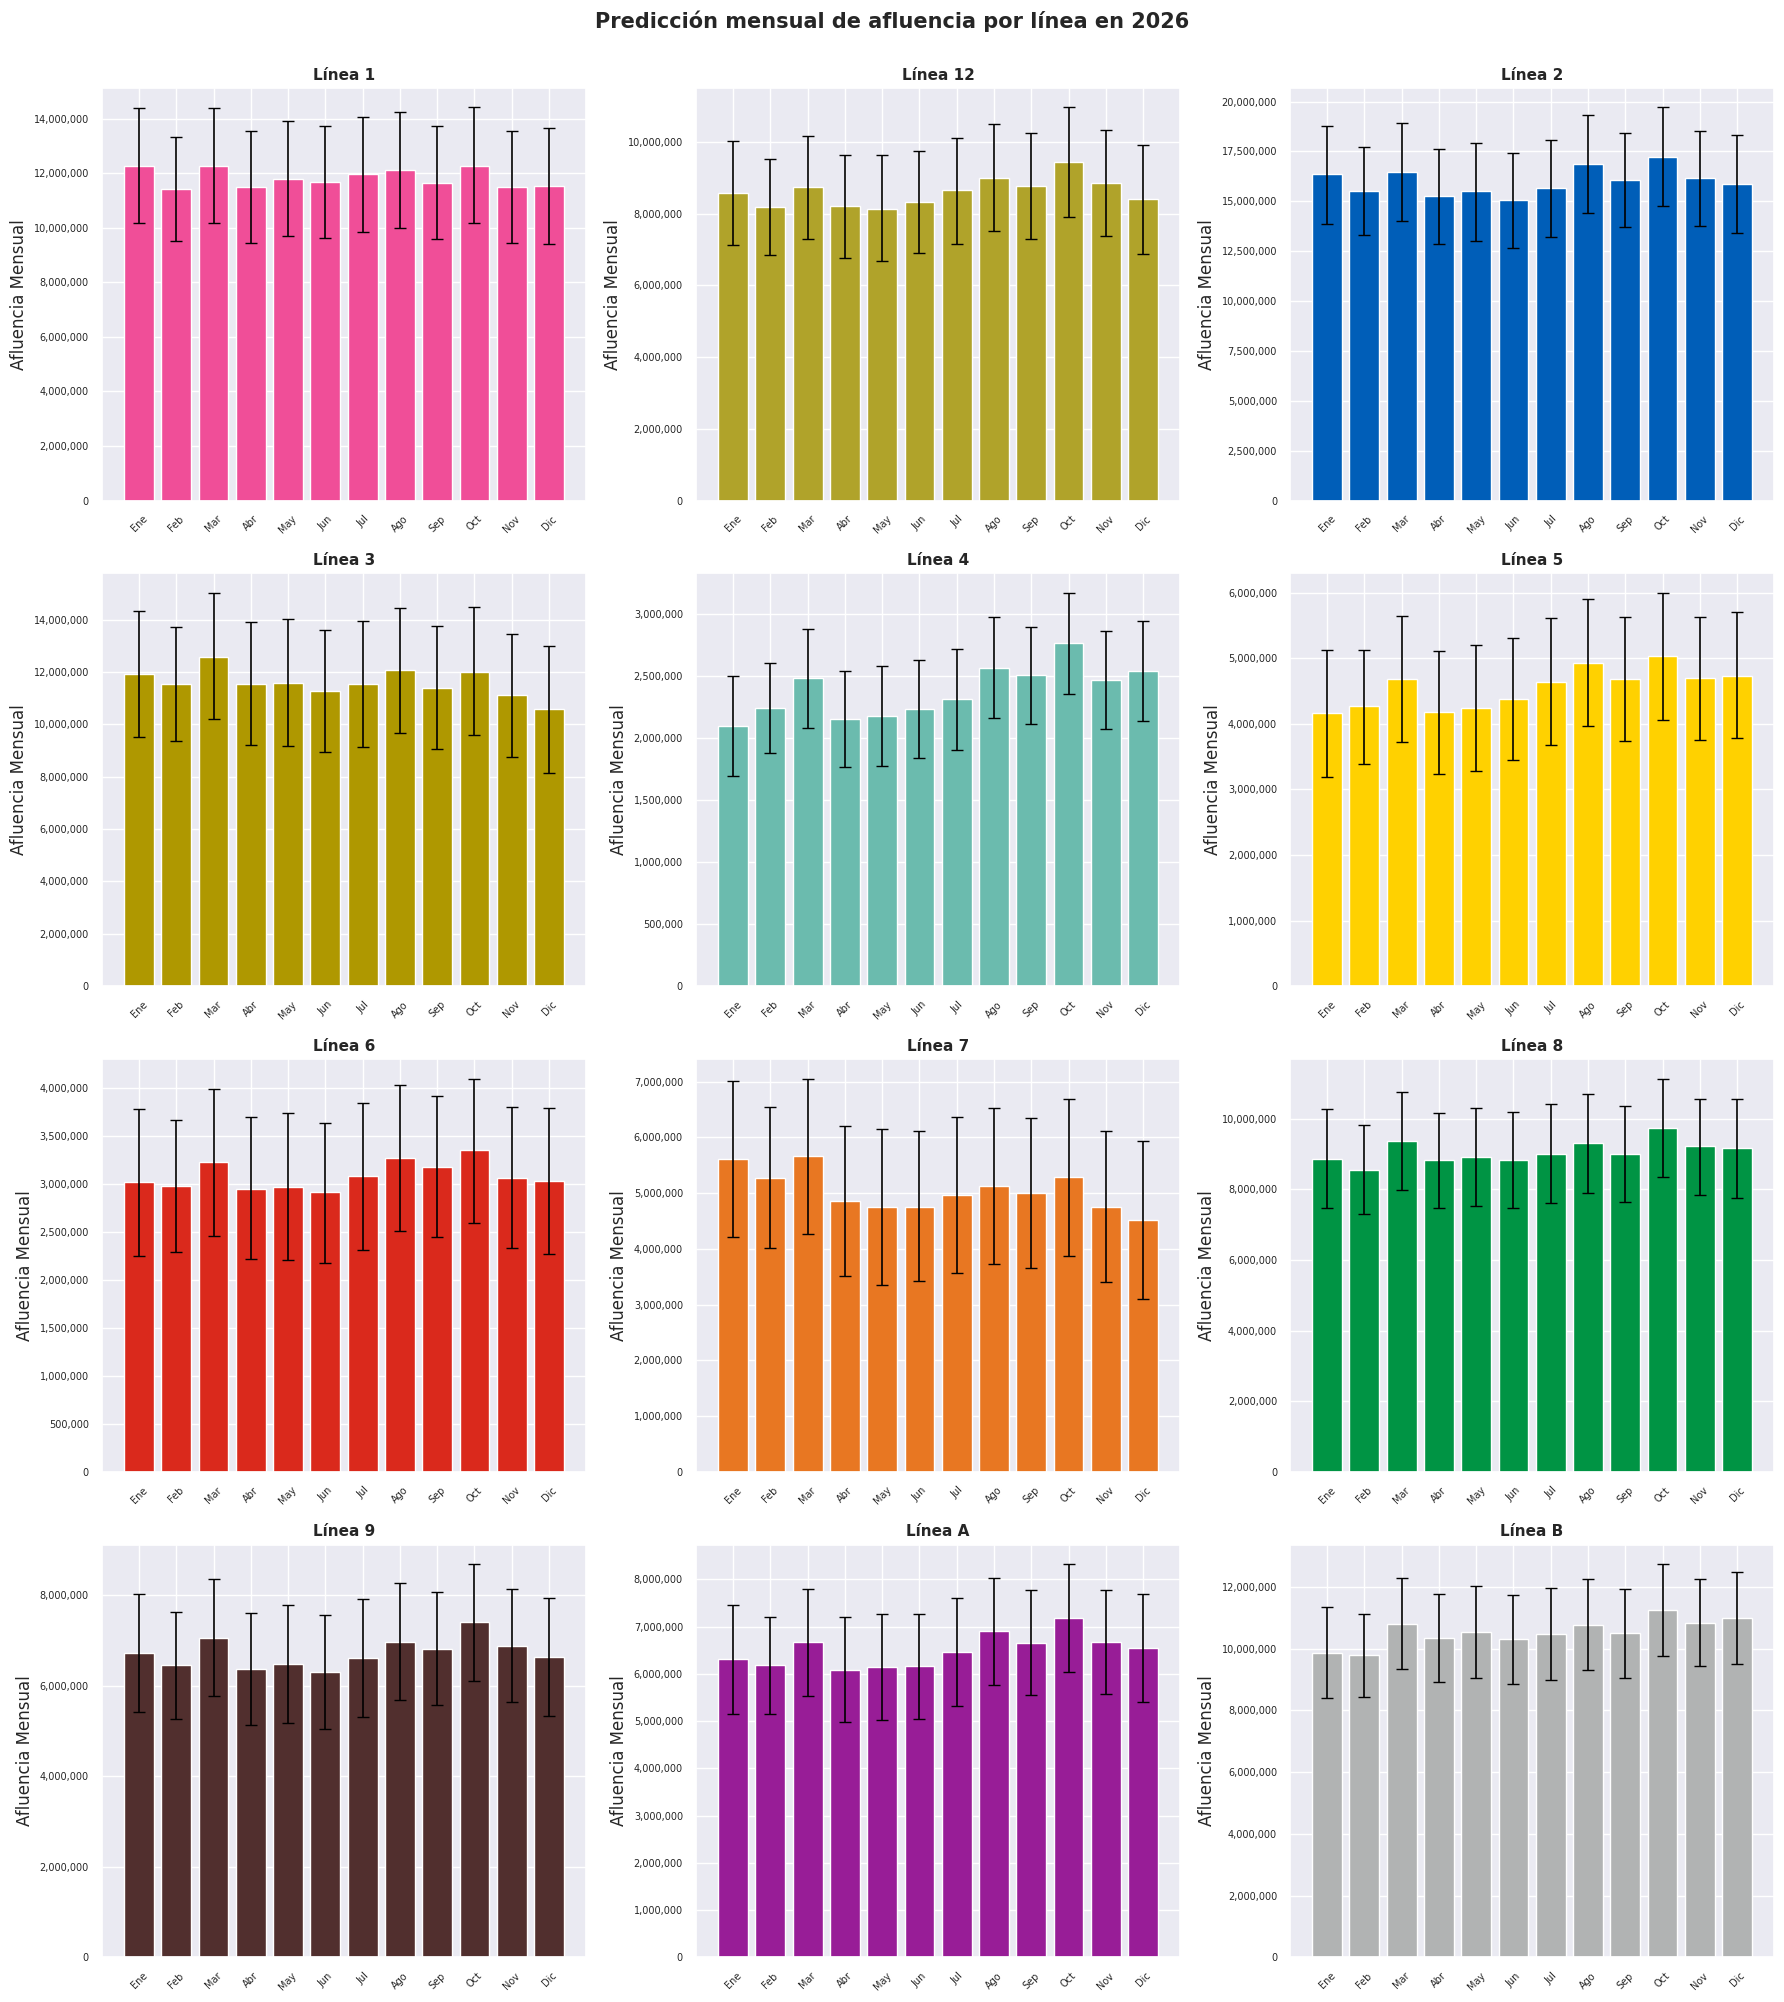

In [83]:
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']


fig,axes = plt.subplots(4,3,figsize=(18,20),sharey=False)
axes = axes.flatten()

for i,linea in enumerate(sorted(forecasts_prophet.keys())):
    ax = axes[i]
    forecast_linea = forecasts_prophet[linea]

    # Predicciones Mensuales 2026
    mensual = (
        forecast_linea[forecast_linea['ds'].dt.year == 2026]
        .groupby(forecast_linea['ds'].dt.month)
        .agg(
            yhat=('yhat','sum'),
            yhat_lower=('yhat_lower','sum'),
            yhat_upper=('yhat_upper','sum')
        )
        .reset_index()
        .rename(columns={'ds':'mes'})
    )
    mensual['mes_nom'] = orden_meses

    # Barplot mensual
    ax.bar(
        mensual['mes_nom'],
        mensual['yhat'],
        color=colores_metro[linea]
    )

    # Intervalo de Confianza
    ax.errorbar(
        mensual['mes_nom'],
        mensual['yhat'],
        yerr= [
            mensual['yhat'] - mensual['yhat_lower'],
            mensual['yhat_upper'] - mensual['yhat']
        ],
        fmt = 'none',color='black',capsize=4,linewidth=1.2,zorder=3
    )
    ax.set_xlabel('')
    ax.tick_params(axis='x',rotation=45,labelsize=7)
    ax.set_ylabel('Afluencia Mensual')
    ax.tick_params(axis='y',labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(linea,fontsize=11,fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predicción mensual de afluencia por línea en 2026',
             fontsize=15, fontweight='bold',y=1)
plt.tight_layout()
plt.savefig('/content/visualizaciones/22_prediccion_mensual_2026_lineas.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [69]:
# import shutil

# shutil.make_archive('/content/visualizaciones', 'zip', '/content/visualizaciones')

# from google.colab import files
# files.download('/content/visualizaciones.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>